# Group Project3
## Submitted by: Vikas Gautam, Gaurav, Miklos
## Date: 24/03/2025

## Step 1

In [ ]:
!pip install arch
!pip install pyts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 23.2 MB/s eta 0:00:00


## Import Libraries/Packages

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from pyts.image import GramianAngularField
from tensorflow.keras.layers import Conv2D, MaxPooling2D

In [ ]:
from arch import arch_model
import warnings
warnings.filterwarnings("ignore")
import tensorflow as tf
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

## Download SPY data from yfinace

In [ ]:
# Download SPY data from Yahoo Finance
start_date = "2010-02-01"
end_date = "2023-12-31"
data = yf.download("SPY", start=start_date, end=end_date)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [ ]:
data.shape

(3503, 5)

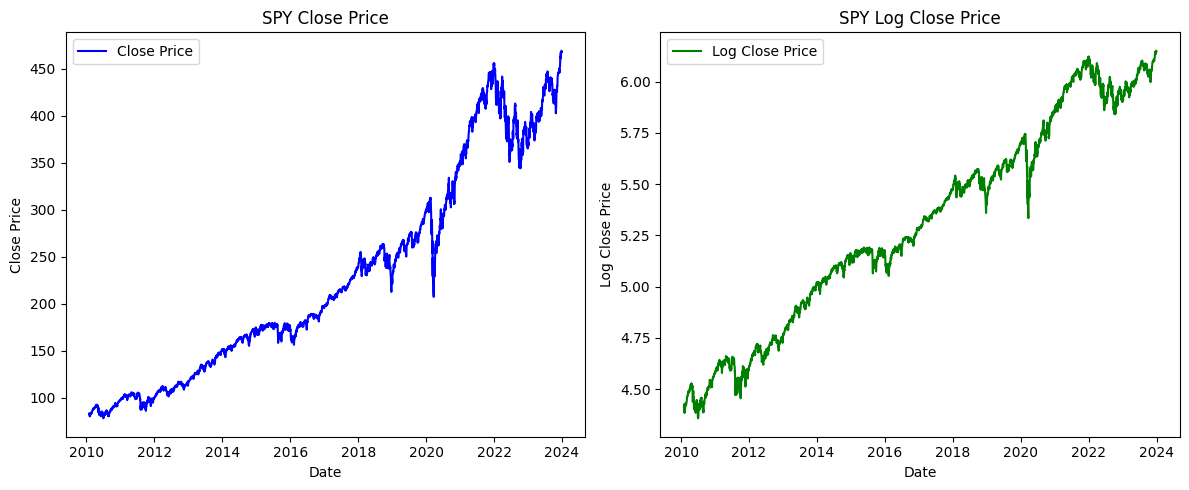

In [ ]:


# Calculate log close price
data['Log_Close'] = np.log(data['Close'])

# Plot Close & Log Close
plt.figure(figsize=(12, 5))

# Plot Close Price
plt.subplot(1, 2, 1)
plt.plot(data.index, data['Close'], label="Close Price", color='blue')
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("SPY Close Price")
plt.legend()

# Plot Log Close Price
plt.subplot(1, 2, 2)
plt.plot(data.index, data['Log_Close'], label="Log Close Price", color='green')
plt.xlabel("Date")
plt.ylabel("Log Close Price")
plt.title("SPY Log Close Price")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Compute log returns
data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))
data['Log_Return']=data['Log_Return']*100
# Introduce features
data['Returrn.Lag1'] = data['Log_Return'].shift(1)
data['Returrn.Lag3'] = data['Log_Return'].shift(3)
data['Returrn.Lag5'] = data['Log_Return'].shift(5)
data['Returrn.F.Lag1'] = data['Log_Return'].shift(-1)
data['Returrn.F.Lag3'] = data['Log_Return'].shift(-3)
data['Returrn.F.Lag5'] = data['Log_Return'].shift(-5)
data['MA_5'] = data['Log_Return'].shift(5).rolling(5).mean()
data['MA_10'] = data['Close'].shift(10).rolling(10).mean()
data['MA_20'] = data['Log_Return'].shift(20).rolling(20).mean()
data['Rolling_Volatility5'] = data['Log_Return'].shift(5).rolling(5).std()
data['Rolling_Volatility10'] = data['Log_Return'].shift(10).rolling(10).std()
# data['LogReturn_5'] = data['Log_Return'].shift(5)
# data['LogReturn_10'] = data['Log_Return'].shift(10)
# Introduce features (with leakage!)
data['Future_MA_10'] = data['Log_Return'].shift(-10).rolling(10).mean()  # Using future data!
data['Future_MA_20'] = data['Log_Return'].shift(-20).rolling(20).mean()
data['Future_Volatility'] = data['Log_Return'].shift(-10).rolling(10).std()

data.dropna(inplace=True)  # Drop NaN values from feature engineering

In [ ]:
data.columns = data.columns.droplevel(1)
data.head(3)

Price,Close,High,Low,Open,Volume,Log_Close,Log_Return,Returrn.Lag1,Returrn.Lag3,Returrn.Lag5,...,Returrn.F.Lag3,Returrn.F.Lag5,MA_5,MA_10,MA_20,Rolling_Volatility5,Rolling_Volatility10,Future_MA_10,Future_MA_20,Future_Volatility
Date,,,,,,,,,,,,,,,,,,,,,
2010-03-30,89.214493,89.541258,88.842134,89.260086,145772500,4.491044,0.068138,0.632716,-0.162741,0.700871,...,0.811604,-0.572851,0.253263,86.706873,0.141923,0.515804,0.445491,0.317729,0.083626,0.523468
2010-03-31,88.910545,89.305701,88.614177,88.872547,161078700,4.487631,-0.341275,0.068138,-0.059981,-0.486683,...,0.235491,0.345805,0.037727,87.070142,0.086223,0.562447,0.438753,0.360105,0.162296,0.479498
2010-04-01,89.518494,89.860455,88.986547,89.518494,161215200,4.494445,0.681448,-0.341275,0.632716,-0.162741,...,-0.572851,0.654591,0.015440,87.403135,0.126315,0.569027,0.462756,0.131558,0.042685,0.767495


In [ ]:


# Compute GARCH(1,1) volatility
def compute_garch_volatility(returns, p=2, q=2):
    garch_model = arch_model(returns, vol='Garch', p=p, q=q, mean='Zero', rescale=False)
    garch_fit = garch_model.fit(disp='off')
    return garch_fit.conditional_volatility

# Apply GARCH model and shift by 5 days
data['GARCH_Vol_5'] = 5*compute_garch_volatility(data['Log_Return']).shift(5).rolling(5).mean()
data['GARCH_Vol_3'] = -3*compute_garch_volatility(data['Log_Return']).shift(3).rolling(3).mean()
data['GARCH_Vol_51'] = 5*compute_garch_volatility(data['Log_Return']).shift(5).rolling(5).std()
data['GARCH_Vol_31'] = -3*compute_garch_volatility(data['Log_Return']).shift(3).rolling(3).std()
# data['GARCH_Fut_5'] = 5*compute_garch_volatility(data['Log_Return']).shift(-5)
# data['GARCH_Fut_3'] = -3*compute_garch_volatility(data['Log_Return']).shift(-3)
# data['GARCH_Fut_51'] = 5*compute_garch_volatility(data['Log_Return']).shift(-5)
# data['GARCH_Fut_31'] = -3*compute_garch_volatility(data['Log_Return']).shift(-3)


In [ ]:
data.dropna(inplace=True)

In [ ]:
# Fit a GARCH(1,1) model
from arch import arch_model

garch_model = arch_model(data["Log_Return"].dropna(), vol="Garch", p=1, q=1)
garch_result = garch_model.fit(disp="off")

# Get conditional volatility (GARCH Vol)
data["GARCH_Vol"] = np.sqrt(garch_result.conditional_volatility)

# Compute 2 × Conditional Standard Deviation (2-csd band)
data["1-CSD"] = 1 * data["GARCH_Vol"]
data["2-CSD"] = 2 * data["GARCH_Vol"]
data["3-CSD"] = 3 * data["GARCH_Vol"]
data["4-CSD"] = 4 * data["GARCH_Vol"]

In [ ]:
data[["Log_Return","GARCH_Vol_3","GARCH_Vol_5","GARCH_Vol_51","GARCH_Vol_31","2-CSD"]].head()

Price,Log_Return,GARCH_Vol_3,GARCH_Vol_5,GARCH_Vol_51,GARCH_Vol_31,2-CSD
Date,,,,,,
2010-04-13,0.075123,-2.587755,5.046025,0.505439,-0.155618,2.424027
2010-04-14,1.128536,-2.460290,4.759941,0.390350,-0.125499,2.303049
2010-04-15,0.082486,-2.345238,4.494073,0.312579,-0.086789,2.259443
2010-04-16,-1.604015,-2.268291,4.311640,0.328116,-0.080487,2.150182
2010-04-19,0.376286,-2.144129,4.124075,0.322560,-0.142970,2.248100


In [ ]:
# Extract GARCH parameters
omega, alpha, beta = garch_result.params["omega"], garch_result.params["alpha[1]"], garch_result.params["beta[1]"]

# Compute Unconditional Standard Deviation (USD)
uncond_std = np.sqrt(omega / (1 - alpha - beta))

# Compute 2 × Unconditional Standard Deviation (2-usd band)
data["2-USD"] = 2 * uncond_std

In [ ]:
data["Spike"] = (data["Log_Return"].abs() > data["2-CSD"]).astype(int)

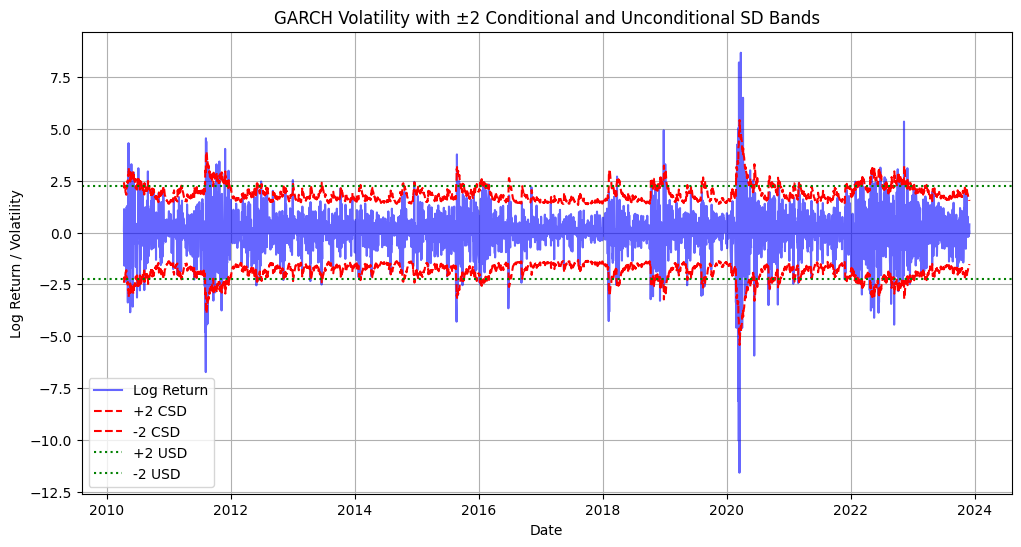

In [ ]:
plt.figure(figsize=(12,6))

# Plot Log Returns
plt.plot(data.index, data["Log_Return"], label="Log Return", color="blue", alpha=0.6)

# Plot ±2-CSD Bands
plt.plot(data.index, data["2-CSD"], label="+2 CSD", color="red", linestyle="dashed")
plt.plot(data.index, -data["2-CSD"], label="-2 CSD", color="red", linestyle="dashed")

# Plot ±2-USD Bands (Long-run volatility)
plt.axhline(y=uncond_std * 2, color="green", linestyle="dotted", label="+2 USD")
plt.axhline(y=-uncond_std * 2, color="green", linestyle="dotted", label="-2 USD")

plt.legend()
plt.title("GARCH Volatility with ±2 Conditional and Unconditional SD Bands")
plt.xlabel("Date")
plt.ylabel("Log Return / Volatility")
plt.grid()
plt.show()

In [ ]:
data.dropna(inplace=True)

## Train Test Split

In [ ]:
# Define features (X) and target (y)
X = data[["MA_5","MA_10","MA_20","Rolling_Volatility5","Rolling_Volatility10",
          'Returrn.Lag1','Returrn.Lag3','Returrn.Lag5',
          'GARCH_Vol_3','GARCH_Vol_5','GARCH_Vol_31','GARCH_Vol_51',
          "1-CSD","2-CSD","3-CSD","4-CSD","Spike",
          # Future information
          'Returrn.F.Lag1','Returrn.F.Lag3','Returrn.F.Lag5',
          "Future_MA_10", "Future_MA_20", "Future_Volatility"]]
y = data['Log_Return']  # Predicting next day's return

# Train-test split (this is also risky, as train and test sets have overlapping info)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Standardize features
scaler1 = StandardScaler()
X_train_scaled = scaler1.fit_transform(X_train)
X_test_scaled = scaler1.transform(X_test)

## Generating Sequnces with window size of 15

In [ ]:
# Reshape data for LSTM (time steps = 5)
time_steps = 15
def reshape_lstm(data, target, time_steps):
    X_lstm, y_lstm = [], []
    for i in range(len(data) - time_steps):
        X_lstm.append(data[i : i + time_steps])
        y_lstm.append(target[i + time_steps])
    return np.array(X_lstm), np.array(y_lstm)

# Standardize features
scaler2 = StandardScaler()
X_scaled = scaler2.fit_transform(X)

# Convert data into LSTM format
X_lstm, y_lstm = reshape_lstm(X_scaled, y.values, time_steps)

# Train-test split
train_size = int(len(X_lstm) * 0.8)
X_train12, X_test12 = X_lstm[:train_size], X_lstm[train_size:]
y_train12, y_test12 = y_lstm[:train_size], y_lstm[train_size:]


In [ ]:
X_train12.shape[1:]

(15, 23)

## Step 1

## MLP

In [ ]:
# Define MLP model with Dropout and Flatten
model1 = Sequential([
    Flatten(input_shape=(X_train12.shape[1:])),
    Dense(128, activation='tanh'),
    Dropout(0.2),
    Dense(64, activation='tanh'),
    Dropout(0.2),
    Dense(32, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='tanh'),
    Dropout(0.2),
    Dense(8, activation='tanh'),
    Dropout(0.2),
    Dense(4, activation='tanh'),
    Dense(1)  # Output layer for regression
])

# Compile the model
model1.compile(optimizer='adam', loss='mse', metrics=['mae'])
# Early stopping callback to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history1 = model1.fit(X_train12, y_train12, validation_split=0.2, epochs=100, batch_size=32, verbose=1, callbacks=[early_stopping])




Epoch 1/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.9643 - mae: 0.7161 - val_loss: 1.5349 - val_mae: 0.6109
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.4930 - mae: 0.4922 - val_loss: 1.3601 - val_mae: 0.5776
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.4127 - mae: 0.4436 - val_loss: 1.2704 - val_mae: 0.5299
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.3639 - mae: 0.4256 - val_loss: 1.2342 - val_mae: 0.5672
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2914 - mae: 0.3807 - val_loss: 1.2167 - val_mae: 0.5451
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2867 - mae: 0.3688 - val_loss: 1.2257 - val_mae: 0.5665
Epoch 7/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2701 - mae: 0.3492 - val_loss: 1.1902 - val_mae: 0.5426
Epoch 8/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3167 - mae: 0.3703 - val_loss: 1.1785 - val_mae: 0.5547
Epoch 9/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - los

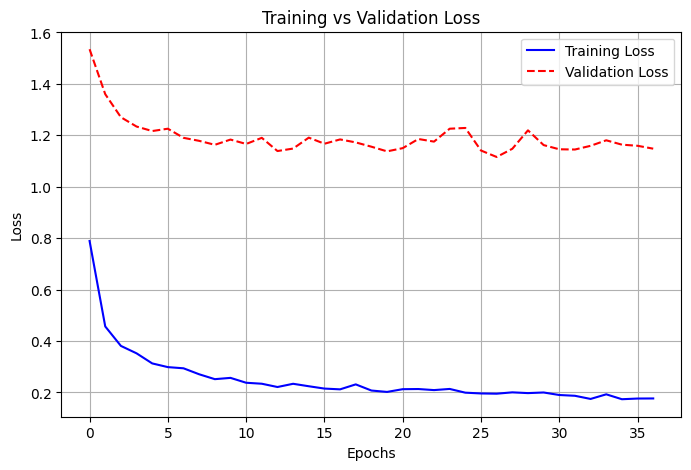

In [ ]:
# Extract loss values
train_loss = history1.history['loss']
val_loss = history1.history['val_loss']

# Plot Loss vs. Validation Loss
plt.figure(figsize=(8,5))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='red', linestyle='dashed')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Extract loss and MAE
train_loss = history1.history['loss']
val_loss = history1.history['val_loss']
train_mae = history1.history['mae']
val_mae = history1.history['val_mae']

# Find the best epoch (minimum validation loss and MAE)
best_epoch_loss = np.argmin(val_loss) + 1  # Adding 1 since epochs start from 1
best_epoch_mae = np.argmin(val_mae) + 1

# Print results
print(f"Best epoch for minimum Validation Loss: {best_epoch_loss}, Loss: {val_loss[best_epoch_loss-1]:.6f}")
print(f"Best epoch for minimum Validation MAE: {best_epoch_mae}, MAE: {val_mae[best_epoch_mae-1]:.6f}")

Best epoch for minimum Validation Loss: 27, Loss: 1.115743
Best epoch for minimum Validation MAE: 14, MAE: 0.517160


In [ ]:
# Predictions and evaluation
y_pred = model1.predict(X_test12).flatten()
r2 = r2_score(y_test12, y_pred)
mae = mean_absolute_error(y_test12, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"R-squared (R²): {r2:.6f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Mean Absolute Error (MAE): 0.394893
R-squared (R²): 0.781396


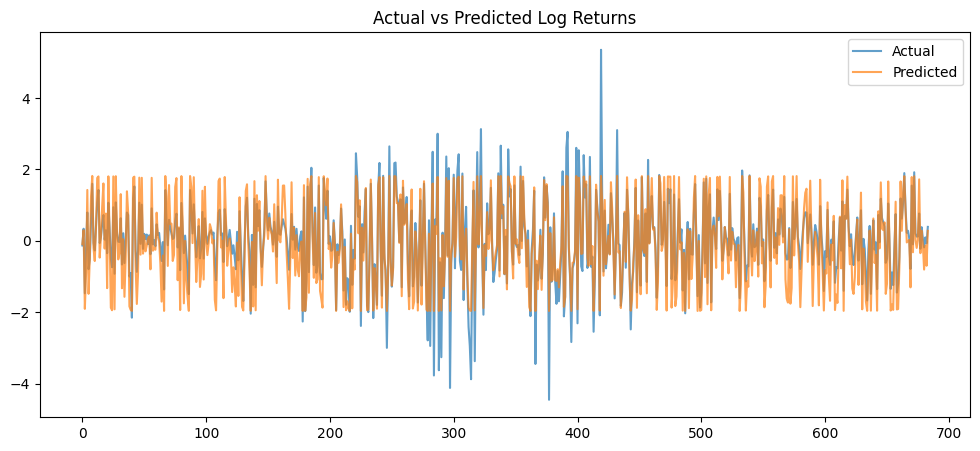

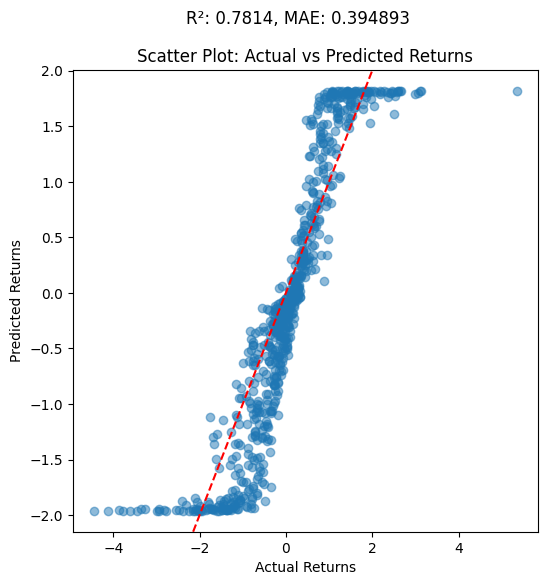

In [ ]:
# Plot actual vs predicted returns
plt.figure(figsize=(12, 5))
plt.plot(y_test12, label='Actual', alpha=0.7)
plt.plot(y_pred, label='Predicted', alpha=0.7)
plt.title("Actual vs Predicted Log Returns")
plt.legend()
plt.show()

# Scatter plot of actual vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test12, y_pred, alpha=0.5)
plt.xlabel("Actual Returns")
plt.ylabel("Predicted Returns")
plt.title("Scatter Plot: Actual vs Predicted Returns")
plt.axline((0, 0), slope=1, color='red', linestyle='--')  # Reference line
title = f"R²: {r2:.4f}, MAE: {mae:.6f}"
plt.suptitle(title)
plt.show()

## LSTM

In [ ]:
X_train12.shape

(2735, 15, 23)

In [30]:
# Define LSTM model
model2 = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(X_train12.shape[1], X_train12.shape[2])),
    Dropout(0.2),
    LSTM(64, activation='tanh', return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='tanh', return_sequences=True),
    Dropout(0.2),
    LSTM(16, activation='tanh', return_sequences=True),
    Dropout(0.2),
    LSTM(8, activation='tanh'),
    Dropout(0.2),
    Dense(1)
])

# Compile model
model2.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train model
history2 = model2.fit(X_train12, y_train12, validation_split=0.2,
                    epochs=100, batch_size=32, verbose=1, callbacks=[early_stopping])

Epoch 1/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 15s 67ms/step - loss: 0.9556 - mae: 0.6716 - val_loss: 2.3337 - val_mae: 0.9067
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.8598 - mae: 0.6496 - val_loss: 2.3281 - val_mae: 0.9009
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 0.8223 - mae: 0.6161 - val_loss: 2.2966 - val_mae: 0.8959
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 0.8565 - mae: 0.6422 - val_loss: 2.2898 - val_mae: 0.8985
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 0.8130 - mae: 0.6260 - val_loss: 2.2715 - val_mae: 0.8891
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.8396 - mae: 0.6339 - val_loss: 2.2966 - val_mae: 0.8889
Epoch 7/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.8459 - mae: 0.6364 - val_loss: 2.2487 - val_mae: 0.8829
Epoch 8/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - loss: 0.8709 - mae: 0.6332 - val_loss: 2.1947 - val_mae: 0.8705
Epoch 9/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - l

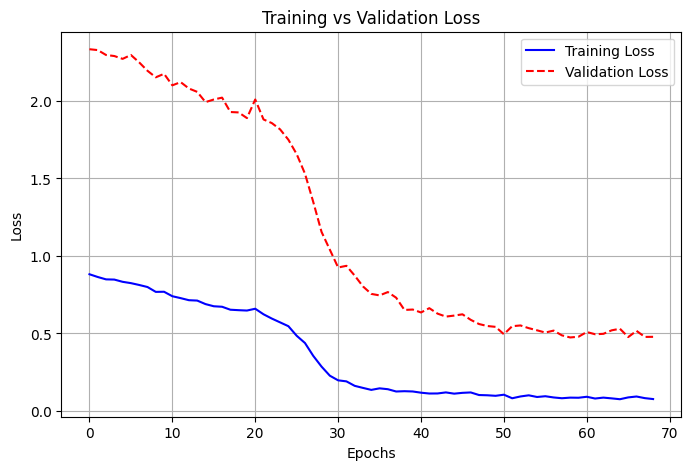

In [31]:
# Extract loss values
train_loss = history2.history['loss']
val_loss = history2.history['val_loss']

# Plot Loss vs. Validation Loss
plt.figure(figsize=(8,5))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='red', linestyle='dashed')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [32]:
# Extract loss and MAE
train_loss = history2.history['loss']
val_loss = history2.history['val_loss']
train_mae = history2.history['mae']
val_mae = history2.history['val_mae']

# Find the best epoch (minimum validation loss and MAE)
best_epoch_loss = np.argmin(val_loss) + 1  # Adding 1 since epochs start from 1
best_epoch_mae = np.argmin(val_mae) + 1

# Print results
print(f"Best epoch for minimum Validation Loss: {best_epoch_loss}, Loss: {val_loss[best_epoch_loss-1]:.6f}")
print(f"Best epoch for minimum Validation MAE: {best_epoch_mae}, MAE: {val_mae[best_epoch_mae-1]:.6f}")

Best epoch for minimum Validation Loss: 59, Loss: 0.473907
Best epoch for minimum Validation MAE: 56, MAE: 0.202897


In [33]:
# Predict
y_pred12 = model2.predict(X_test12)

# Evaluate model
r2 = r2_score(y_test12, y_pred12)
print(f'R² Score: {r2:.4f}')
mae=mean_absolute_error(y_test12, y_pred12)
print(f'MAE Score: {mae:.4f}')

22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step
R² Score: 0.9245
MAE Score: 0.1831


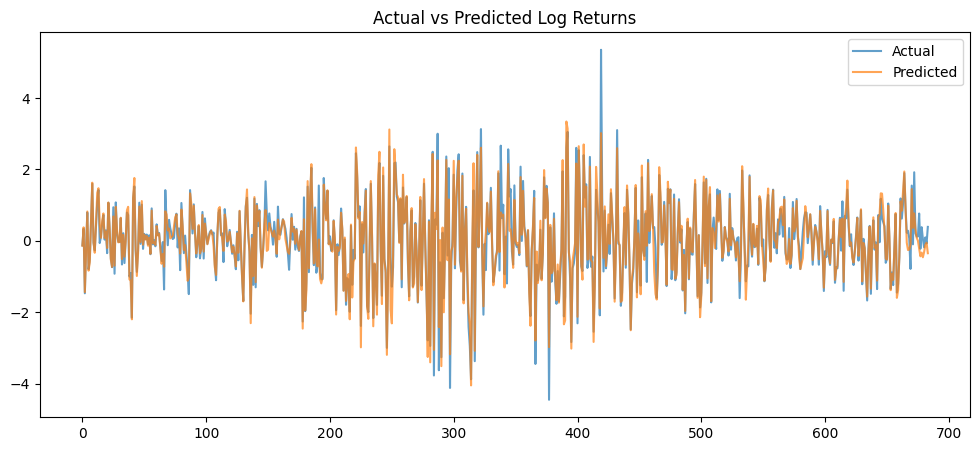

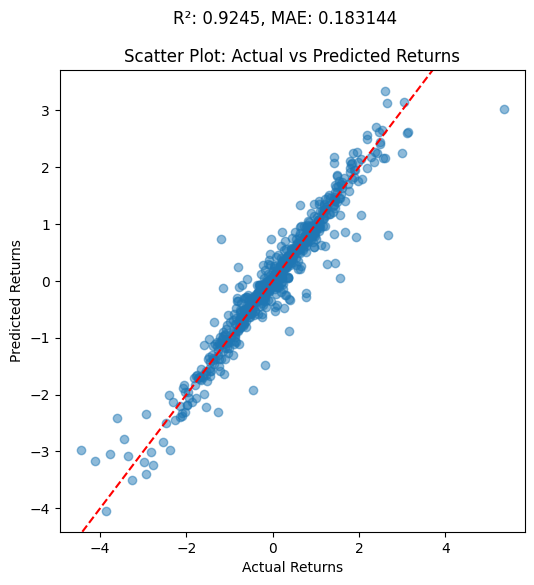

In [34]:
# Plot actual vs predicted returns
plt.figure(figsize=(12, 5))
plt.plot(y_test12, label='Actual', alpha=0.7)
plt.plot(y_pred12, label='Predicted', alpha=0.7)
plt.title("Actual vs Predicted Log Returns")
plt.legend()
plt.show()

# Scatter plot of actual vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test12, y_pred12, alpha=0.5)
plt.xlabel("Actual Returns")
plt.ylabel("Predicted Returns")
plt.title("Scatter Plot: Actual vs Predicted Returns")
plt.axline((0, 0), slope=1, color='red', linestyle='--')  # Reference line
title = f"R²: {r2:.4f}, MAE: {mae:.6f}"
plt.suptitle(title)
plt.show()

### Backtesting LSTM

In [36]:
test_dates = pd.date_range(start=start_date, periods=len(y_test12), freq='B')

df_predictions = pd.DataFrame({
    "Date": test_dates,
    "Pred LSTM": y_pred12.flatten(),
    "DailyRet": y_test12.flatten()
})

Strat Return = -100.0 %
Buy and Hold Return = -100.0 %


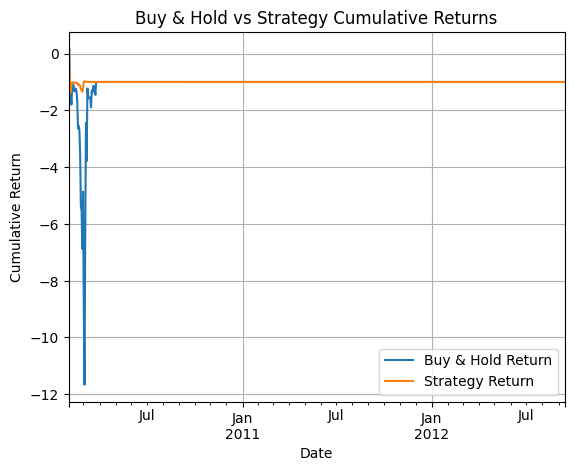

In [37]:
# Generate trading positions based on the sign of the predicted returns.
df_predictions["Positions"] = df_predictions["Pred LSTM"].apply(np.sign)

# Compute strategy returns: use the position from the previous day (shift by 1)
df_predictions["Strat_ret"] = df_predictions["Positions"].shift(1) * df_predictions["DailyRet"]

# Compute cumulative returns for the strategy and for a buy-and-hold approach.
df_predictions["CumRet"] = df_predictions["Strat_ret"].expanding().apply(lambda x: np.prod(1 + x) - 1)
df_predictions["bhRet"] = df_predictions["DailyRet"].expanding().apply(lambda x: np.prod(1 + x) - 1)

# Calculate overall returns for the strategy and for buy-and-hold.
Final_Return = np.prod(1 + df_predictions["Strat_ret"].fillna(0)) - 1
Buy_Return = np.prod(1 + df_predictions["DailyRet"]) - 1

print("Strat Return =", Final_Return * 100, "%")
print("Buy and Hold Return =", Buy_Return * 100, "%")

# Plot cumulative returns
ax = plt.gca()
df_predictions.plot(x="Date", y="bhRet", ax=ax, label="Buy & Hold Return")
df_predictions.plot(x="Date", y="CumRet", ax=ax, label="Strategy Return")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Buy & Hold vs Strategy Cumulative Returns")
plt.grid(True)

## CNN model based on GAF

In [ ]:
# Convert time series to GAF images
gaf = GramianAngularField(image_size=15, method='difference')
X_train_gaf = np.array([gaf.fit_transform(x.reshape(1, -1)) for x in X_train_scaled])
X_test_gaf = np.array([gaf.fit_transform(x.reshape(1, -1)) for x in X_test_scaled])

# Reshape for CNN input (batch, height, width, channels)
X_train_gaf = X_train_gaf.reshape(-1, 15, 15, 1)
X_test_gaf = X_test_gaf.reshape(-1, 15, 15, 1)

## Subsequnces of images for CNN-GAF

In [ ]:
# Reshape data for CNN-GAF (time steps = 5)
time_steps = 15
def reshape_gaf(data, target, time_steps):
    X_gaf, y_gaf = [], []
    for i in range(len(data) - time_steps):
        X_gaf.append(data[i : i + time_steps])
        y_gaf.append(target[i + time_steps])
    return np.array(X_gaf), np.array(y_gaf)

# Convert data into LSTM format
X_train_gaf2, y_train_gaf2 = reshape_gaf(X_train_gaf, y_train.values, time_steps)
X_test_gaf2, y_test_gaf2 = reshape_gaf(X_test_gaf, y_test.values, time_steps)



In [ ]:
X_train_gaf.shape[1:4]

(15, 15, 1)

In [ ]:
# Define CNN model
model3 = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='tanh', input_shape=X_train_gaf2.shape[1:4]),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.2),

    Conv2D(64, kernel_size=(3,3), activation='tanh'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.2),


    Flatten(),
    Dense(128, activation='tanh'),
    Dropout(0.2),
    Dense(1)  # Regression output
])

# Compile model
model3.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train model
history3 = model3.fit(X_train_gaf2, y_train_gaf2, validation_split=0.2,
                    epochs=100, batch_size=32, verbose=1, callbacks=[early_stopping])

Epoch 1/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 1.2159 - mae: 0.8052 - val_loss: 2.1637 - val_mae: 0.8604
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.8166 - mae: 0.6627 - val_loss: 2.0726 - val_mae: 0.8238
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.6867 - mae: 0.5989 - val_loss: 1.9842 - val_mae: 0.8054
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.6167 - mae: 0.5581 - val_loss: 1.8371 - val_mae: 0.7676
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.5944 - mae: 0.5506 - val_loss: 1.8228 - val_mae: 0.7967
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5279 - mae: 0.5192 - val_loss: 1.8002 - val_mae: 0.8083
Epoch 7/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4828 - mae: 0.5152 - val_loss: 1.7407 - val_mae: 0.7301
Epoch 8/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4537 - mae: 0.4780 - val_loss: 1.6270 - val_mae: 0.6616
Epoch 9/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss:

In [ ]:
# Extract loss and MAE
train_loss = history3.history['loss']
val_loss = history3.history['val_loss']
train_mae = history3.history['mae']
val_mae = history3.history['val_mae']

# Find the best epoch (minimum validation loss and MAE)
best_epoch_loss = np.argmin(val_loss) + 1  # Adding 1 since epochs start from 1
best_epoch_mae = np.argmin(val_mae) + 1

# Print results
print(f"Best epoch for minimum Validation Loss: {best_epoch_loss}, Loss: {val_loss[best_epoch_loss-1]:.6f}")
print(f"Best epoch for minimum Validation MAE: {best_epoch_mae}, MAE: {val_mae[best_epoch_mae-1]:.6f}")

Best epoch for minimum Validation Loss: 55, Loss: 1.114182
Best epoch for minimum Validation MAE: 55, MAE: 0.504625


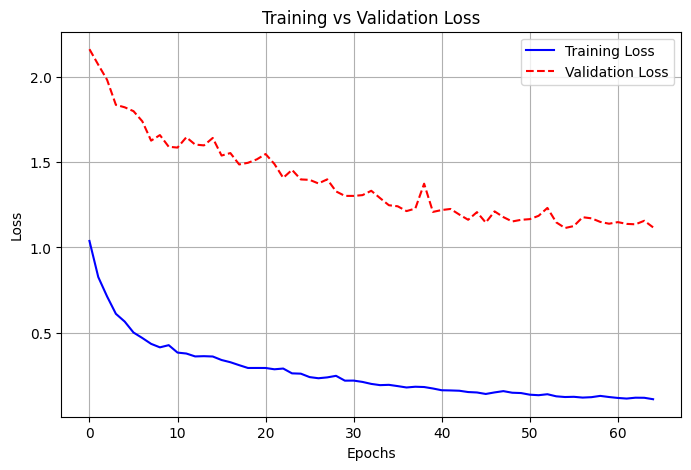

In [ ]:
# Plot training loss vs validation loss
plt.figure(figsize=(8,5))
plt.plot(history3.history['loss'], label='Training Loss', color='blue')
plt.plot(history3.history['val_loss'], label='Validation Loss', color='red', linestyle='dashed')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Predict
y_pred13 = model3.predict(X_test_gaf2)

# Evaluate model
r2 = r2_score(y_test_gaf2, y_pred13)
print(f'R² Score: {r2:.4f}')
mae=mean_absolute_error(y_test_gaf2, y_pred13)
print(f'MAE Score: {mae:.4f}')

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
R² Score: 0.7382
MAE Score: 0.3801


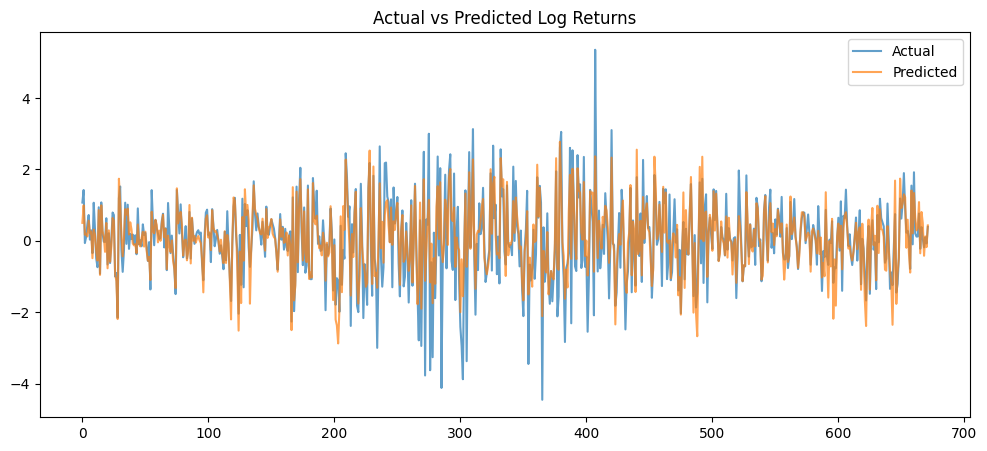

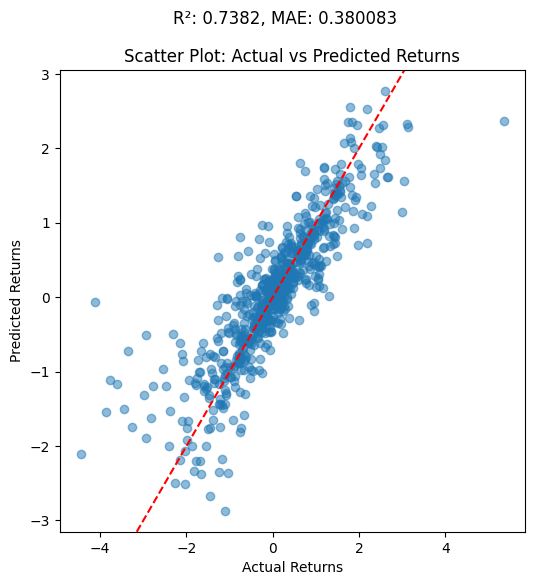

In [ ]:
# Plot actual vs predicted returns
plt.figure(figsize=(12, 5))
plt.plot(y_test_gaf2, label='Actual', alpha=0.7)
plt.plot(y_pred13, label='Predicted', alpha=0.7)
plt.title("Actual vs Predicted Log Returns")
plt.legend()
plt.show()

# Scatter plot of actual vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test_gaf2, y_pred13, alpha=0.5)
plt.xlabel("Actual Returns")
plt.ylabel("Predicted Returns")
plt.title("Scatter Plot: Actual vs Predicted Returns")
plt.axline((0, 0), slope=1, color='red', linestyle='--')  # Reference line
title = f"R²: {r2:.4f}, MAE: {mae:.6f}"
plt.suptitle(title)
plt.show()

## Step 2

## Walk Forward: MLP

In [ ]:
def create_model1(input_shape,input_shape2):

    model = Sequential([
        Flatten(input_shape=([input_shape,input_shape2])),
        Dense(128, activation='tanh'),
        Dropout(0.2),
        Dense(64, activation='tanh'),
        Dropout(0.2),
        Dense(32, activation='tanh'),
        Dropout(0.2),
        Dense(16, activation='tanh'),
        Dropout(0.2),
        Dense(8, activation='tanh'),
        Dropout(0.2),
        Dense(4, activation='tanh'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


In [ ]:
X_train12.shape

(2735, 15, 23)

## Train Test split:500:500

In [ ]:
scaler = MinMaxScaler()
X_scaled21 = scaler.fit_transform(X)

window_size21 = 500  # Train size = 500, Test size = 500
step_size21 = 500  # Shift window by 100 observations per iteration

r2_scores21 = []
mae_scores21 = []
num_splits21 = (len(X_train12) -  window_size21) // step_size21
y_actual_best21 = None
y_pred_best21 = None
best_r21 = -np.inf
best_model21 = None
mae21=-np.inf
train_loss = None
val_loss = None

for i in range(num_splits21):
    train_start = i * step_size21
    train_end = train_start + window_size21
    test_start = train_end
    test_end = test_start + window_size21

    X_train21, X_test21 = X_train12[train_start:train_end], X_train12[test_start:test_end]
    y_train21, y_test21 = y_train12[train_start:train_end], y_train12[test_start:test_end]

    model4 = create_model1(X_train21.shape[1],X_train21.shape[2])
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history4 = model4.fit(X_train21, y_train21, validation_split=0.2,
                        epochs=100, batch_size=32, verbose=0, callbacks=[early_stopping])

    y_pred21 = model4.predict(X_test21).flatten()
    r2 = r2_score(y_test21, y_pred21)
    mae = mean_absolute_error(y_test21, y_pred21)
    r2_scores21.append(r2)
    mae_scores21.append(mae)
    if r2 > best_r21:
        best_r21 = r2
        mae21=mae
        best_model21 = model4
        y_actual_best21 = y_test21
        y_pred_best21 = y_pred21
        train_loss = history4.history['loss']
        val_loss = history4.history['val_loss']
    print(f"Iteration {i+1}/{num_splits21} - R²: {r2:.4f}, MAE: {mae:.6f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Iteration 1/4 - R²: 0.7685, MAE: 0.262047
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Iteration 2/4 - R²: 0.8471, MAE: 0.228892
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Iteration 3/4 - R²: 0.7742, MAE: 0.201584
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Iteration 4/4 - R²: 0.4658, MAE: 0.427021


In [ ]:
print ("Best R-squared:",best_r21)
print ("Corresponding MAE:",mae21)
print ("Training Loss: ", np.min(train_loss))
print ("Validation Loss: ", np.min(val_loss))

NameError: name 'best_r21' is not defined

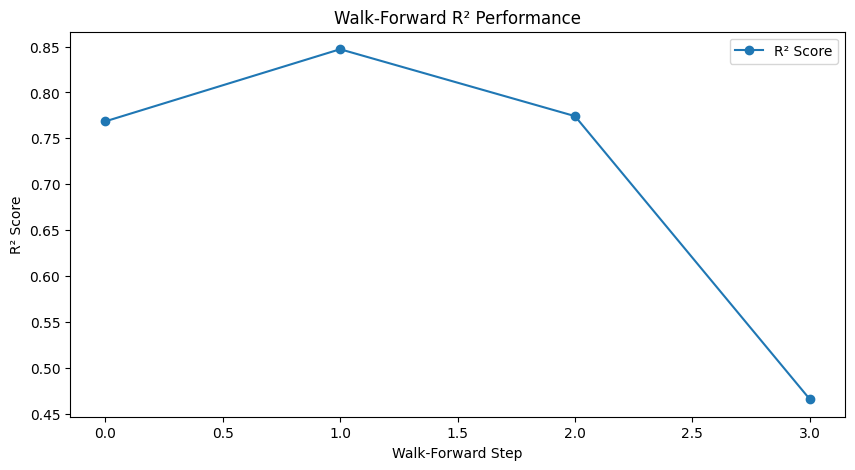

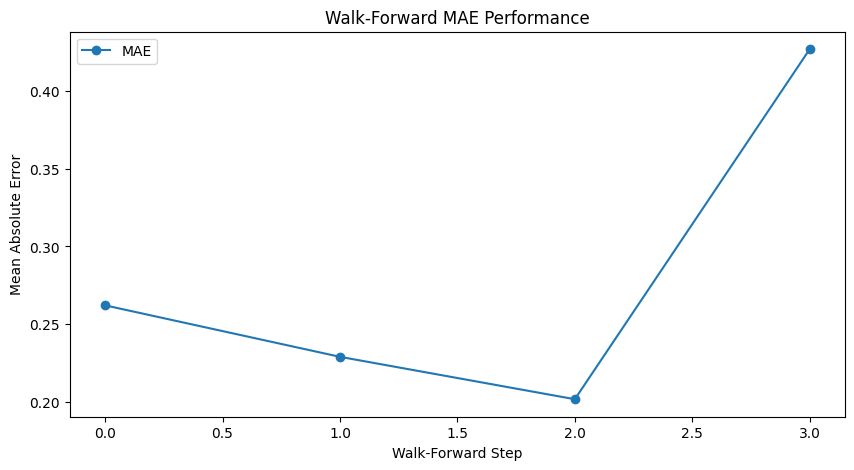

In [ ]:
# Plot R² scores over iterations
plt.figure(figsize=(10, 5))
plt.plot(r2_scores21, marker='o', label='R² Score')
plt.xlabel('Walk-Forward Step')
plt.ylabel('R² Score')
plt.title('Walk-Forward R² Performance')
plt.legend()
plt.show()

# Plot MAE over iterations
plt.figure(figsize=(10, 5))
plt.plot(mae_scores21, marker='o', label='MAE')
plt.xlabel('Walk-Forward Step')
plt.ylabel('Mean Absolute Error')
plt.title('Walk-Forward MAE Performance')
plt.legend()
plt.show()


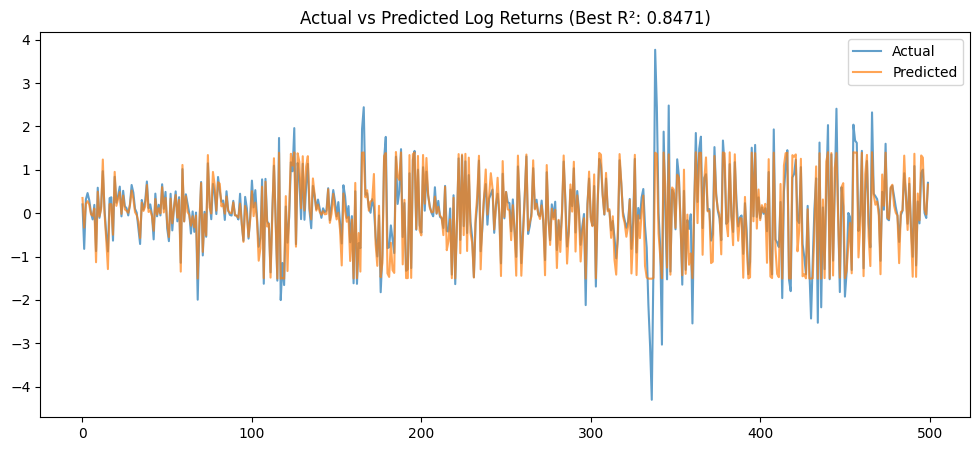

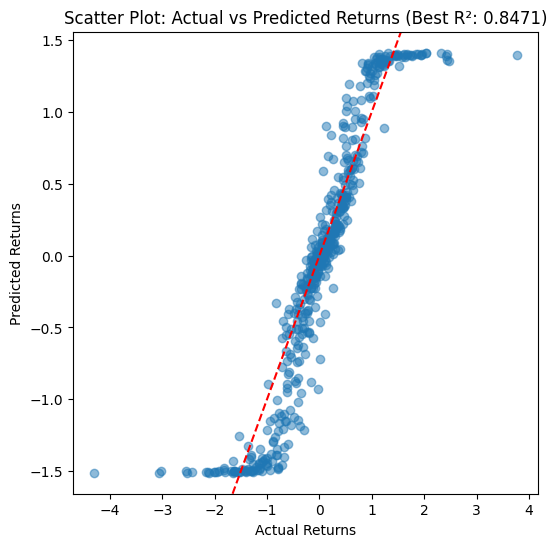

In [ ]:
# Plot Actual vs Predicted for Best R²
plt.figure(figsize=(12, 5))
plt.plot(y_actual_best21, label='Actual', alpha=0.7)
plt.plot(y_pred_best21, label='Predicted', alpha=0.7)
plt.title(f"Actual vs Predicted Log Returns (Best R²: {best_r21:.4f})")
plt.legend()
plt.show()

# Scatter Plot of Best Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_actual_best21, y_pred_best21, alpha=0.5)
plt.xlabel("Actual Returns")
plt.ylabel("Predicted Returns")
plt.title(f"Scatter Plot: Actual vs Predicted Returns (Best R²: {best_r21:.4f})")
plt.axline((0, 0), slope=1, color='red', linestyle='--')
plt.show()


In [ ]:
# Predictions and evaluation
y_pred21 = best_model21.predict(X_test12).flatten()
r2 = r2_score(y_test12, y_pred21)
mae = mean_absolute_error(y_test12, y_pred21)

print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"R-squared (R²): {r2:.6f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Mean Absolute Error (MAE): 0.331295
R-squared (R²): 0.803242


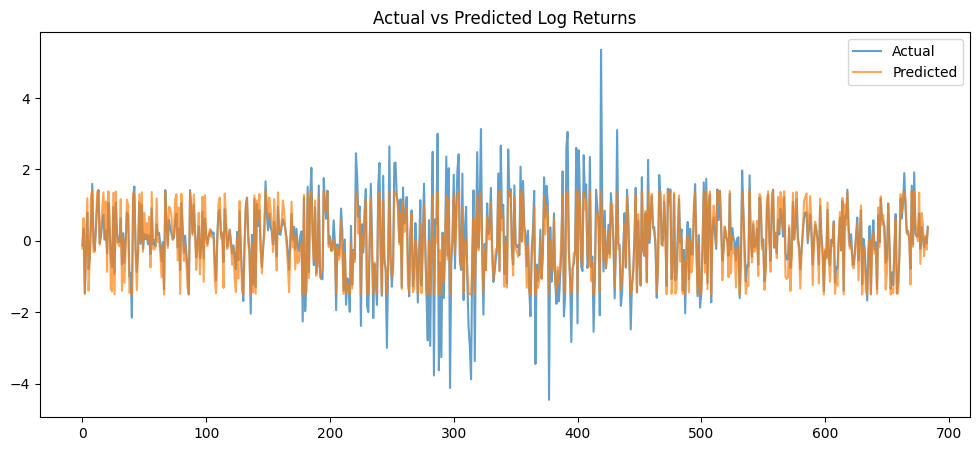

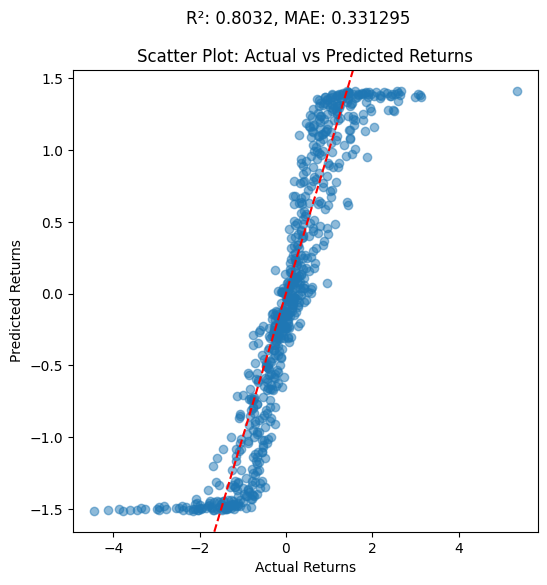

In [ ]:
# Plot actual vs predicted returns
plt.figure(figsize=(12, 5))
plt.plot(y_test12, label='Actual', alpha=0.7)
plt.plot(y_pred21, label='Predicted', alpha=0.7)
plt.title("Actual vs Predicted Log Returns")
plt.legend()
plt.show()

# Scatter plot of actual vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test12, y_pred21, alpha=0.5)
plt.xlabel("Actual Returns")
plt.ylabel("Predicted Returns")
plt.title("Scatter Plot: Actual vs Predicted Returns")
plt.axline((0, 0), slope=1, color='red', linestyle='--')  # Reference line
title = f"R²: {r2:.4f}, MAE: {mae:.6f}"
plt.suptitle(title)
plt.show()

## Train test split: 500:100

In [ ]:
train_size22 = 500  # Train set size
test_size22 = 100   # Test set size
step_size22 = 500   # Shift window by 100 observations per iteration

r2_scores22 = []
mae_scores22 = []
y_actual_best22 = None
y_pred_best22 = None
best_r22 = -np.inf
best_model22 = None
mae22=-np.inf
num_splits22 = (len(X_train12) - (train_size22)) // step_size22

for i in range(num_splits22):
    train_start = i * step_size22
    train_end = train_start + train_size22
    test_start = train_end
    test_end = test_start + test_size22

    X_train22, X_test22 = X_train12[train_start:train_end], X_train12[test_start:test_end]
    y_train22, y_test22 = y_train12[train_start:train_end], y_train12[test_start:test_end]

    model5 = create_model1(X_train22.shape[1],X_train22.shape[2])
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history5 = model5.fit(X_train22, y_train22, validation_split=0.2,
                        epochs=100, batch_size=32, verbose=0, callbacks=[early_stopping])

    y_pred22 = model5.predict(X_test22).flatten()
    r2 = r2_score(y_test22, y_pred22)
    mae = mean_absolute_error(y_test22, y_pred22)
    r2_scores22.append(r2)
    mae_scores22.append(mae)

    if r2 > best_r22:
        best_r22 = r2
        best_model22 = model5
        mae22=mae
        y_actual_best22 = y_test22
        y_pred_best22 = y_pred22
        train_loss = history5.history['loss']
        val_loss = history5.history['val_loss']
    print(f"Iteration {i+1}/{num_splits22} - R²: {r2:.4f}, MAE: {mae:.6f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Iteration 1/4 - R²: 0.8852, MAE: 0.225051
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Iteration 2/4 - R²: 0.8246, MAE: 0.145229


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Iteration 3/4 - R²: 0.7367, MAE: 0.244758
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Iteration 4/4 - R²: 0.8353, MAE: 0.161164


In [ ]:
print ("Best R-squared:",best_r22)
print ("Corresponding MAE:",mae22)
print ("Training Loss: ", np.min(train_loss))
print ("Validation Loss: ", np.min(val_loss))

Best R-squared: 0.8852005866906549
Corresponding MAE: 0.22505090779990955
Training Loss:  0.4476800560951233
Validation Loss:  0.08762440085411072


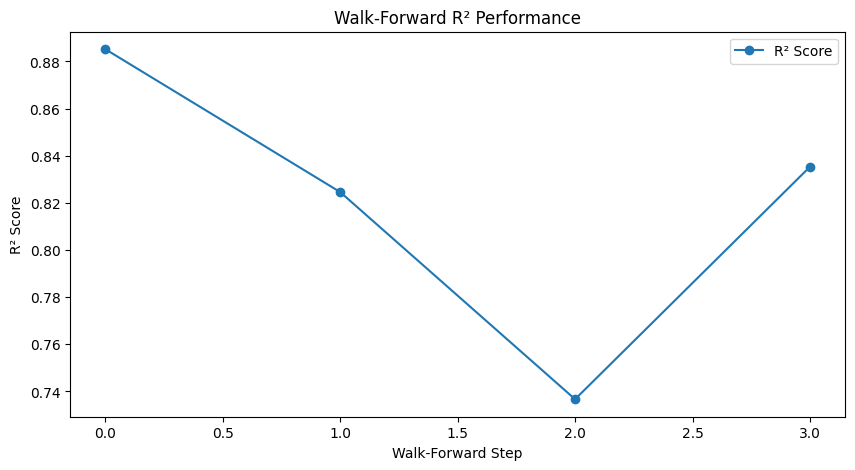

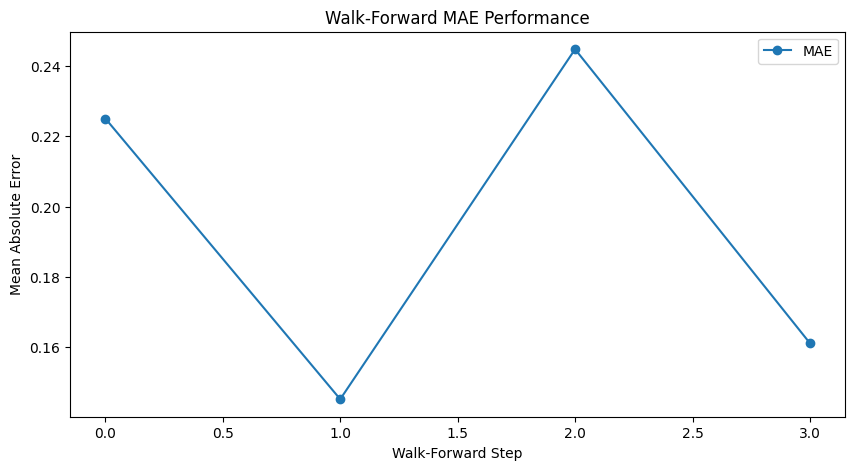

In [ ]:
# Plot R² scores over iterations
plt.figure(figsize=(10, 5))
plt.plot(r2_scores22, marker='o', label='R² Score')
plt.xlabel('Walk-Forward Step')
plt.ylabel('R² Score')
plt.title('Walk-Forward R² Performance')
plt.legend()
plt.show()

# Plot MAE over iterations
plt.figure(figsize=(10, 5))
plt.plot(mae_scores22, marker='o', label='MAE')
plt.xlabel('Walk-Forward Step')
plt.ylabel('Mean Absolute Error')
plt.title('Walk-Forward MAE Performance')
plt.legend()
plt.show()

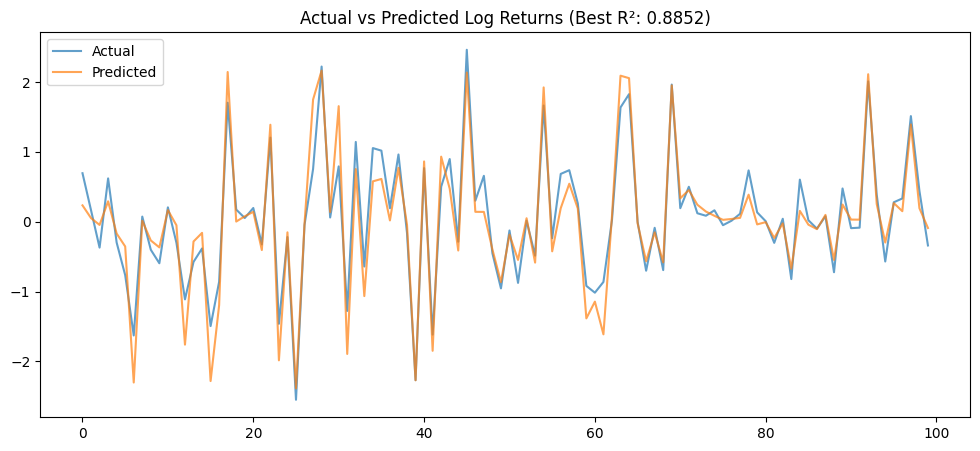

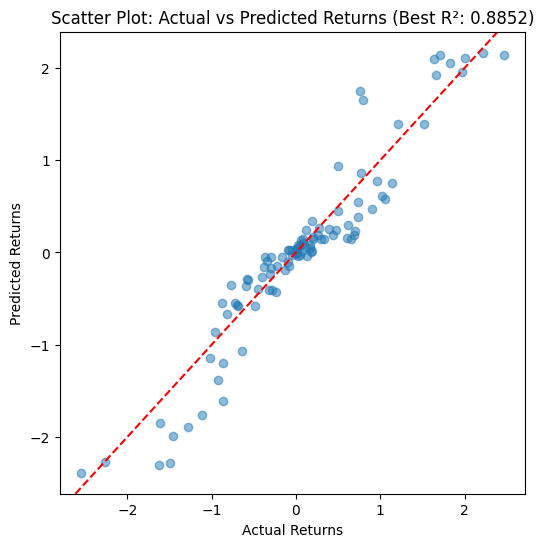

In [ ]:
# Plot Actual vs Predicted for Best R²
plt.figure(figsize=(12, 5))
plt.plot(y_actual_best22, label='Actual', alpha=0.7)
plt.plot(y_pred_best22, label='Predicted', alpha=0.7)
plt.title(f"Actual vs Predicted Log Returns (Best R²: {best_r22:.4f})")
plt.legend()
plt.show()

# Scatter Plot of Best Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_actual_best22, y_pred_best22, alpha=0.5)
plt.xlabel("Actual Returns")
plt.ylabel("Predicted Returns")
plt.title(f"Scatter Plot: Actual vs Predicted Returns (Best R²: {best_r22:.4f})")
plt.axline((0, 0), slope=1, color='red', linestyle='--')
plt.show()


In [ ]:
# Predictions and evaluation
y_pred22 = best_model22.predict(X_test12).flatten()

r2 = r2_score(y_test12, y_pred22)
mae = mean_absolute_error(y_test12, y_pred22)

print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"R-squared (R²): {r2:.6f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Mean Absolute Error (MAE): 0.528484
R-squared (R²): 0.683141


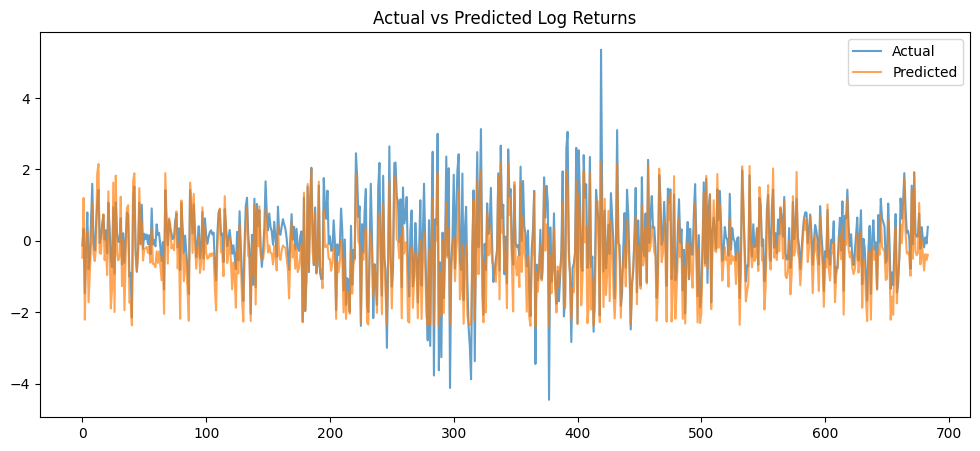

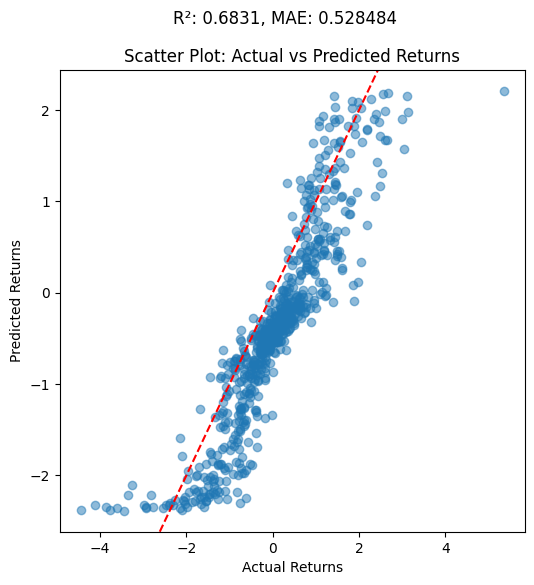

In [ ]:
# Plot actual vs predicted returns
plt.figure(figsize=(12, 5))
plt.plot(y_test12, label='Actual', alpha=0.7)
plt.plot(y_pred22, label='Predicted', alpha=0.7)
plt.title("Actual vs Predicted Log Returns")
plt.legend()
plt.show()

# Scatter plot of actual vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test12, y_pred22, alpha=0.5)
plt.xlabel("Actual Returns")
plt.ylabel("Predicted Returns")
plt.title("Scatter Plot: Actual vs Predicted Returns")
plt.axline((0, 0), slope=1, color='red', linestyle='--')  # Reference line
title = f"R²: {r2:.4f}, MAE: {mae:.6f}"
plt.suptitle(title)
plt.show()

## Walk Forward: LSTM



```
# This is formatted as code
```

## Train: Test split: 500:500

In [ ]:
# Download hourly SPY data (limit: last 60 days)
spy = yf.download("SPY", period="60d", interval="1h")
spy.columns = spy.columns.droplevel(1)

# Display the first few rows
print(spy.head(3))

[*********************100%***********************]  1 of 1 completed

Price                           Close        High         Low        Open  \
Datetime                                                                    
2024-12-26 14:30:00+00:00  600.289978  600.400024  598.082520  599.500000   
2024-12-26 15:30:00+00:00  600.830017  601.278503  599.789978  600.284973   
2024-12-26 16:30:00+00:00  601.510010  602.479980  600.799988  600.840027   

Price                       Volume  
Datetime                            
2024-12-26 14:30:00+00:00  5803845  
2024-12-26 15:30:00+00:00  3073697  
2024-12-26 16:30:00+00:00  2775121  


In [ ]:
# Assuming 'data' is your DataFrame
spy.index = pd.to_datetime(spy.index)  # Ensure datetime format
spy = spy.asfreq('h')  # Set frequency to hourly

spy.head(3)

Price,Close,High,Low,Open,Volume
Datetime,,,,,
2024-12-26 14:30:00+00:00,600.289978,600.400024,598.082520,599.500000,5803845.0
2024-12-26 15:30:00+00:00,600.830017,601.278503,599.789978,600.284973,3073697.0
2024-12-26 16:30:00+00:00,601.510010,602.479980,600.799988,600.840027,2775121.0


In [ ]:
spy = spy[[ "Close", "Volume"]]
spy["Returns"] = spy["Close"].pct_change()

# spy["Returns"] = spy["Returns"].fillna(0)
# spy["Volume"] = spy["Volume"].fillna(0)
#
spy.info(3)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2142 entries, 2024-12-26 14:30:00+00:00 to 2025-03-25 19:30:00+00:00
Freq: h
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Close    420 non-null    float64
 1   Volume   420 non-null    float64
 2   Returns  2141 non-null   float64
dtypes: float64(3)
memory usage: 66.9 KB


In [ ]:
df = spy[["Returns"]]*100
df=df.dropna()
n_lags = 24 * 10

for i in range(1, n_lags + 1):
    name = "Ret_" + str(i)
    df[name] = df["Returns"].shift(i)

df["Ret5_i"] = df["Returns"].rolling(3).apply(lambda x: 100 * (np.prod(1 + x / 100) - 1))
df["Ret5"] = df["Ret5_i"].shift(-3)
df["Output"] = df["Ret5"] > 0
df["Output"] = df["Output"].astype(int)
del df["Ret5"]
del df["Ret5_i"]

df = df.dropna()
df.head(5)


Price,Returns,Ret_1,Ret_2,Ret_3,Ret_4,Ret_5,Ret_6,Ret_7,Ret_8,Ret_9,...,Ret_232,Ret_233,Ret_234,Ret_235,Ret_236,Ret_237,Ret_238,Ret_239,Ret_240,Output
Datetime,,,,,,,,,,,,,,,,,,,,,
2025-01-05 15:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.093055,0.148103,-0.127970,0.026595,0.113176,0.089963,0
2025-01-05 16:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,-0.093055,0.148103,-0.127970,0.026595,0.113176,0
2025-01-05 17:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,-0.093055,0.148103,-0.127970,0.026595,0
2025-01-05 18:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,-0.093055,0.148103,-0.127970,0
2025-01-05 19:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,-0.093055,0.148103,0


In [ ]:
df2=df.copy()

In [ ]:
X, y = df.iloc[:, 1:-1], df.iloc[:, -1]
print(X.shape, y.shape)

(1901, 240) (1901,)


In [ ]:
# Reshape data for LSTM (time steps = 5)
time_steps = 15
def reshape_lstm(data, target, time_steps):
    X_lstm, y_lstm = [], []
    for i in range(len(data) - time_steps):
        X_lstm.append(data[i : i + time_steps])
        y_lstm.append(target[i + time_steps])

    return np.array(X_lstm), np.array(y_lstm)


# Convert data into LSTM format
X_lstm2, y_lstm2 = reshape_lstm(X, y.values,time_steps)

# Train-test split
train_size2 = int(len(X_lstm2) * 0.8)
X1_train23, X1_test23 = X_lstm2[:train_size2], X_lstm2[train_size2:]
y1_train23, y1_test23 = y_lstm2[:train_size2], y_lstm2[train_size2:]


In [ ]:
X1_train23.shape

(1508, 15, 240)

In [ ]:
# Walk-forward parameters
train_size23 = 500
test_size23 = 500
time_steps23 = 500

# Store results
r2_scores23 = []
mae_scores23 = []
best_r23 = -np.inf
best_model23 = None
mae23=-np.inf
best_model23 = None
best_preds23 = None
best_y_test23 = None
train_loss = None
val_loss = None
accuracy_scores23=[]
f1_scores23=[]
best_acc23 = -np.inf
best_f123 = -np.inf
batch_size = 32  # Set a fixed batch size
time_steps = 15
num_features = 23  # Your feature count

# Walk-forward loop
for start in range(0, len(X1_train23) - train_size23 , time_steps23):
    X_train23, X_test23 = X1_train23[start:start+train_size23], X1_train23[start+train_size23:start+train_size23+test_size23]
    y_train23, y_test23 = y1_train23[start:start+train_size23],y1_train23[start+train_size23:start+train_size23+test_size23]

    # Define LSTM model
    # model6 = Sequential([
    #     LSTM(128, activation='tanh', return_sequences=True, input_shape=(time_steps, num_features)),
    #     Dropout(0.2),
    #     LSTM(64, activation='tanh', return_sequences=True),
    #     Dropout(0.2),
    #     LSTM(32, activation='tanh', return_sequences=True),
    #     Dropout(0.2),
    #     LSTM(16, activation='tanh', return_sequences=True),
    #     Dropout(0.2),
    #     LSTM(8, activation='tanh'),
    #     Dropout(0.2),
    #     Dense(1)
    # ])
    # Define LSTM model
    model6 = Sequential([
        LSTM(128, activation='tanh', return_sequences=True, input_shape=(X1_train23.shape[1],X1_train23.shape[2])),
        Dropout(0.2),
        LSTM(64, activation='tanh', return_sequences=True),
        Dropout(0.2),
        LSTM(32, activation='tanh', return_sequences=True),
        Dropout(0.2),
        LSTM(16, activation='tanh', return_sequences=True),
        Dropout(0.2),
        LSTM(8, activation='tanh'),
        Dropout(0.2),
        Dense(1)
    ])

    # Compile model
    model6.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    from sklearn.utils.class_weight import compute_class_weight
    import numpy as np

    # Define class weights manually
    class_weight = {0: 0.5, 1: 5.5}  # Higher weight for class 1

    # Train model
    history6=model6.fit(X_train23, y_train23, validation_split=0.2,
              epochs=100, batch_size=batch_size, verbose=0, callbacks=[early_stopping],class_weight=class_weight)

    # Predict
    y_pred23 = model6.predict(X_test23)

    # Evaluate classification performance
    accuracy = accuracy_score(y_test23, (y_pred23 > 0.5).astype(int))  # Convert probs to binary
    f1 = f1_score(y_test23, (y_pred23 > 0.5).astype(int))
    precision = precision_score(y_test23, (y_pred23 > 0.5).astype(int))
    recall = recall_score(y_test23, (y_pred23 > 0.5).astype(int))

    accuracy_scores23.append(accuracy)
    f1_scores23.append(f1)

    # Store best model
    if accuracy > best_acc23:  # Compare accuracy instead of R²
        best_acc23 = accuracy
        best_f123 = f1
        best_model23 = model6
        train_loss = history6.history['loss']
        val_loss = history6.history['val_loss']
        best_preds23 = y_pred23
        best_y_test23 = y_test23

    print(f'Walk {start//time_steps23+1}: Accuracy = {accuracy:.4f}, F1 Score = {f1:.4f}, Precision = {precision:.4f}, Recall = {recall:.4f}')

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
Walk 1: Accuracy = 0.8400, F1 Score = 0.0000, Precision = 0.0000, Recall = 0.0000
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
Walk 2: Accuracy = 0.8000, F1 Score = 0.3333, Precision = 0.2717, Recall = 0.4310
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step
Walk 3: Accuracy = 0.6250, F1 Score = 0.0000, Precision = 0.0000, Recall = 0.0000


In [ ]:
print("Best Accuracy:", best_acc23)
print("Corresponding F1 Score:", best_f123)
print("Training Loss:", np.min(train_loss))
print("Validation Loss:", np.min(val_loss))

Best Accuracy: 0.84
Corresponding F1 Score: 0.0
Training Loss: 0.04827312380075455
Validation Loss: 0.15636010468006134


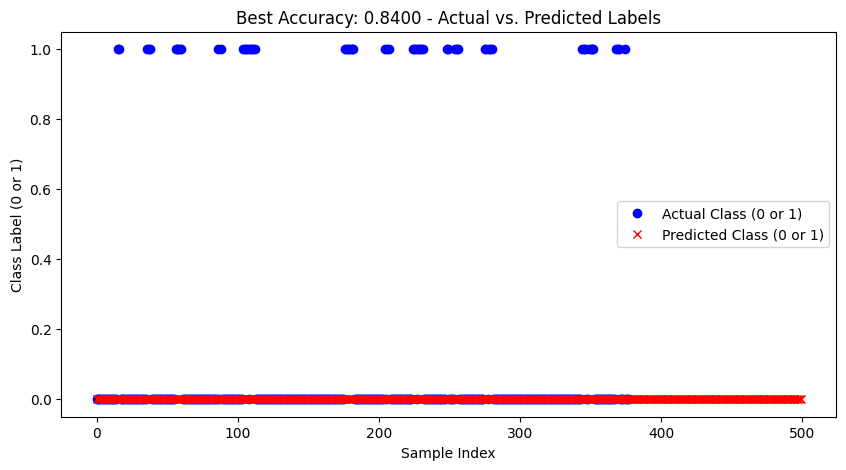

In [ ]:
y_pred231=(best_preds23 > 0.5).astype(int)
# Plot Actual vs. Predicted for Best Accuracy
plt.figure(figsize=(10,5))
plt.plot(y1_test23, label='Actual Class (0 or 1)', color='blue', marker='o', linestyle='')
plt.plot(y_pred231, label='Predicted Class (0 or 1)', color='red', marker='x', linestyle='')
plt.legend()
plt.title(f'Best Accuracy: {best_acc23:.4f} - Actual vs. Predicted Labels')
plt.xlabel("Sample Index")
plt.ylabel("Class Label (0 or 1)")
plt.show()

In [ ]:
# Predictions and evaluation
y1_pred23 = best_model23.predict(X1_test23).flatten()

accuracy = accuracy_score(y1_test23, (y1_pred23 > 0.5).astype(int))  # Convert probs to binary
f1 = f1_score(y1_test23, (y1_pred23 > 0.5).astype(int))
precision = precision_score(y1_test23, (y1_pred23 > 0.5).astype(int))
recall = recall_score(y1_test23, (y1_pred23 > 0.5).astype(int))
print ("accuracy:",accuracy)
print ("f1:",f1)
print ("precision:",precision)
print ("recall:",recall)


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
accuracy: 0.8359788359788359
f1: 0.06060606060606061
precision: 0.25
recall: 0.034482758620689655


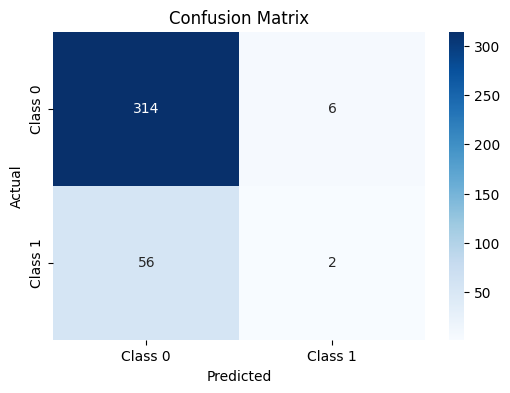

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       320
           1       0.25      0.03      0.06        58

    accuracy                           0.84       378
   macro avg       0.55      0.51      0.49       378
weighted avg       0.76      0.84      0.78       378



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
y_pred = (y1_pred23 > 0.5).astype(int)
# Compute confusion matrix
cm = confusion_matrix(y1_test23, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(y1_test23, y_pred))


In [ ]:
df3 = spy[["Returns"]]*100

n_lags = 24 * 10

for i in range(1, n_lags + 1):
    name = "Ret_" + str(i)
    df3[name] = df3["Returns"].shift(i)

df3["Ret5_i"] = df3["Returns"].rolling(4).apply(lambda x: 100 * (np.prod(1 + x / 100) - 1))
df3["Ret5"] = df3["Ret5_i"].shift(-4)
df3["Output"] = df3["Ret5"] > 0
df3["Output"] = df3["Output"].astype(int)
del df3["Ret5"]
del df3["Ret5_i"]

df3 = df3.dropna()
df3.head(5)


Price,Returns,Ret_1,Ret_2,Ret_3,Ret_4,Ret_5,Ret_6,Ret_7,Ret_8,Ret_9,...,Ret_232,Ret_233,Ret_234,Ret_235,Ret_236,Ret_237,Ret_238,Ret_239,Ret_240,Output
Datetime,,,,,,,,,,,,,,,,,,,,,
2025-01-05 15:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.093055,0.148103,-0.127970,0.026595,0.113176,0.089963,0
2025-01-05 16:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,-0.093055,0.148103,-0.127970,0.026595,0.113176,0
2025-01-05 17:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,-0.093055,0.148103,-0.127970,0.026595,0
2025-01-05 18:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,-0.093055,0.148103,-0.127970,0
2025-01-05 19:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,-0.093055,0.148103,0


In [ ]:
train_size = int(0.8 * len(X))
X, y = df3.iloc[:, 1:-1], df3.iloc[:, -1]
X1=X.iloc[:train_size]
X1_test=X.iloc[train_size:]
y1=y.iloc[:train_size]
y1_test=y.iloc[train_size:]
print(X1.shape, y1.shape,X1_test.shape, y1_test.shape)

(1520, 240) (1520,) (381, 240) (381,)


In [ ]:
X1.head(3)

Price,Ret_1,Ret_2,Ret_3,Ret_4,Ret_5,Ret_6,Ret_7,Ret_8,Ret_9,Ret_10,...,Ret_231,Ret_232,Ret_233,Ret_234,Ret_235,Ret_236,Ret_237,Ret_238,Ret_239,Ret_240
Datetime,,,,,,,,,,,,,,,,,,,,,
2025-01-05 15:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,-0.093055,0.148103,-0.127970,0.026595,0.113176,0.089963
2025-01-05 16:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,-0.093055,0.148103,-0.127970,0.026595,0.113176
2025-01-05 17:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,-0.093055,0.148103,-0.127970,0.026595


In [ ]:
hp_units = 85
hp_units_2 = 55
hp_units_3 = 30
n_dropout = 0.2
act_fun = "relu"

In [ ]:
n_train = 500
n_test = 500

time_backtest = []
time_backtest = np.array(time_backtest)
time_backtest = time_backtest.astype("datetime64", copy=False)

pred_backtest = []
ret_backtest = []

for i in range(0, len(y1) - n_train, n_test):
    X_train, X_test = X1[i : i + (n_train)], X1[i + n_train : i + n_train + n_test]
    y_train, y_test = y1[i : i + (n_train)], y1[i + n_train : i + n_train + n_test]

    # test_time = X1.index[i + n_train : i + n_train + n_test].
    # Ensure test_time is in datetime format
    test_time = X1.index[i + n_train : i + n_train + n_test].values
    df_selected = X1[i + n_train : i + n_train + n_test]

    # If you need only the first column:
    Ret_vector = df_selected.iloc[:, 0].values  #
    # Ret_vector = df.loc[test_time, 0:1].values
    print(
        "ite ",
        i / n_test,
        " -- start test:",
        test_time[0],
        " -- end test",
        test_time[-1],
        " ------- ",
        X_train.shape,
        y_train.shape,
        X_test.shape,
        y_test.shape,
        test_time.shape,
        Ret_vector.shape,
    )
    tf.keras.backend.clear_session()
    tf.random.set_seed(1234)

    model6 = tf.keras.models.Sequential()
    model6.add(tf.keras.layers.Dense(units=hp_units, activation=act_fun))
    model6.add(tf.keras.layers.Dropout(n_dropout))
    model6.add(tf.keras.layers.Dense(units=hp_units_2, activation=act_fun))
    model6.add(tf.keras.layers.Dropout(n_dropout))
    model6.add(tf.keras.layers.Dense(units=hp_units_3, activation=act_fun))
    model6.add(tf.keras.layers.Dropout(n_dropout))
    model6.add(tf.keras.layers.Dense(units=1, activation="sigmoid"))

    hp_lr = 1e-5

    adam = tf.keras.optimizers.Adam(learning_rate=hp_lr)
    model6.compile(optimizer=adam, loss="binary_crossentropy", metrics=["accuracy"])

    es = tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        verbose=0,
        patience=20,
        restore_best_weights=True,
    )
    class_weight = {0: 1, 1: 1.5}
    history6 = model6.fit(
        X_train,
        y_train,
        validation_split=0.15,
        epochs=500,
        batch_size=32,
        verbose=0,
        callbacks=[es],
        class_weight=class_weight,
    )

    y_prob = model6.predict(X_test, verbose=0)
    y_pred = np.where(y_prob > 0.50, 1, 0)

    time_backtest = np.append(time_backtest, test_time.flatten())
    pred_backtest = np.append(pred_backtest, y_pred.flatten())
    ret_backtest = np.append(ret_backtest, Ret_vector.flatten())

df_predictions = pd.DataFrame({"Date": time_backtest, "Pred": pred_backtest, "Ret": ret_backtest})

ite  0.0  -- start test: 2025-01-26T11:30:00.000000000  -- end test 2025-02-16T06:30:00.000000000  -------  (500, 240) (500,) (500, 240) (500,) (500,) (500,)
ite  1.0  -- start test: 2025-02-16T07:30:00.000000000  -- end test 2025-03-09T02:30:00.000000000  -------  (500, 240) (500,) (500, 240) (500,) (500,) (500,)
ite  2.0  -- start test: 2025-03-09T03:30:00.000000000  -- end test 2025-03-09T22:30:00.000000000  -------  (500, 240) (500,) (20, 240) (20,) (20,) (20,)


In [ ]:
df_predictions.loc[df_predictions["Pred"] == 0, "Pred"] = -1

df_res = df_predictions
df_res.tail()

,Date,Pred,Ret
1015,2025-03-09 18:30:00,-1.0,0.0
1016,2025-03-09 19:30:00,-1.0,0.0
1017,2025-03-09 20:30:00,-1.0,0.0
1018,2025-03-09 21:30:00,-1.0,0.0
1019,2025-03-09 22:30:00,-1.0,0.0


In [ ]:
df_res["Positions"] = np.where(df_res["Pred"] > 0.5, 1, -1)
df_res["Positions_shift"] = df_res["Positions"].shift(1)
df_res["Strat_ret"] = df_res["Positions"].shift(1) * df_res["Ret"]
df_res["Positions_L"] = df_res["Positions"].shift(1)
df_res["Positions_L"][df_res["Positions_L"] == -1] = 0
df_res["Strat_ret_L"] = df_res["Positions_L"] * df_res["Ret"]
df_res["CumRet"] = df_res["Strat_ret"].expanding().apply(lambda x: np.prod(1 + x) - 1)
df_res["CumRet_L"] = (
    df_res["Strat_ret_L"].expanding().apply(lambda x: np.prod(1 + x) - 1)
)
df_res["bhRet"] = df_res["Ret"].expanding().apply(lambda x: np.prod(1 + x) - 1)

Final_Return_L = np.prod(1 + df_res["Strat_ret_L"]) - 1
Final_Return = np.prod(1 + df_res["Strat_ret"]) - 1
Buy_Return = np.prod(1 + df_res["Ret"]) - 1

print("Strat Return Long Only =", Final_Return_L * 100, "%")
print("Strat Return =", Final_Return * 100, "%")
print("Buy and Hold Return =", Buy_Return * 100, "%")

Strat Return Long Only = -100.15753770278404 %
Strat Return = -100.00000114873421 %
Buy and Hold Return = -99.99999999116172 %


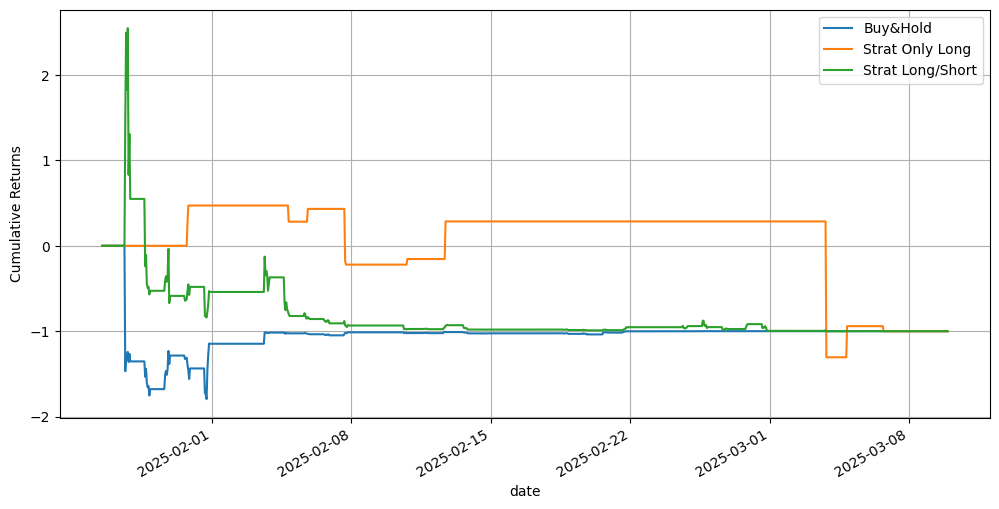

,Date,Pred,Ret,Positions,Positions_shift,Strat_ret,Positions_L,Strat_ret_L,CumRet,CumRet_L,bhRet,trade_bin
count,1020,1020.000000,1020.000000,1020.000000,1019.000000,1019.000000,1019.000000,1019.000000,1019.000000,1019.000000,1020.000000,1019.000000
mean,2025-02-16 17:00:00,-0.927451,-0.005165,-0.927451,-0.927380,-0.000544,0.036310,-0.002857,-0.819434,0.037887,-1.036638,0.064769
min,2025-01-26 11:30:00,-1.000000,-1.619940,-1.000000,-1.000000,-1.237899,0.000000,-1.237899,-1.002855,-1.305850,-1.795818,0.000000
25%,2025-02-06 02:15:00,-1.000000,0.000000,-1.000000,-1.000000,-0.000000,0.000000,0.000000,-0.988201,-0.154804,-1.028568,0.000000
50%,2025-02-16 17:00:00,-1.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,-0.953380,0.285631,-1.013456,0.000000
75%,2025-02-27 07:45:00,-1.000000,0.000000,-1.000000,-1.000000,-0.000000,0.000000,0.000000,-0.857729,0.285631,-1.000000,0.000000
max,2025-03-09 22:30:00,1.000000,0.855191,1.000000,1.000000,1.619940,1.000000,0.521105,2.548665,0.471859,0.000000,1.000000
std,NaN,0.374128,0.171690,0.374128,0.374305,0.171852,0.187152,0.067160,0.356709,0.483347,0.223385,0.246239


In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 6))
ax = plt.gca()
df_res.plot(x="Date", y="bhRet", label="Buy&Hold", ax=ax)
df_res.plot(x="Date", y="CumRet_L", label="Strat Only Long", ax=ax)
df_res.plot(x="Date", y="CumRet", label="Strat Long/Short", ax=ax)
plt.xlabel("date")
plt.ylabel("Cumulative Returns")
plt.grid()
plt.show()

df_res["trade_bin"] = df_res["Positions"].diff().abs()
df_res["trade_bin"] = df_res["trade_bin"] / 2
df_res.describe()

## Train Test split: 500:100

In [ ]:
df = spy[["Returns"]]*100

n_lags = 24 * 10

for i in range(1, n_lags + 1):
    name = "Ret_" + str(i)
    df[name] = df["Returns"].shift(i)

df["Ret5_i"] = df["Returns"].rolling(3).apply(lambda x: 100 * (np.prod(1 + x / 100) - 1))
df["Ret5"] = df["Ret5_i"].shift(-3)
df["Output"] = df["Ret5"] > 0
df["Output"] = df["Output"].astype(int)
del df["Ret5"]
del df["Ret5_i"]

df = df.dropna()
df.head(5)


Price,Returns,Ret_1,Ret_2,Ret_3,Ret_4,Ret_5,Ret_6,Ret_7,Ret_8,Ret_9,...,Ret_232,Ret_233,Ret_234,Ret_235,Ret_236,Ret_237,Ret_238,Ret_239,Ret_240,Output
Datetime,,,,,,,,,,,,,,,,,,,,,
2025-01-05 15:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.093055,0.148103,-0.127970,0.026595,0.113176,0.089963,0
2025-01-05 16:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,-0.093055,0.148103,-0.127970,0.026595,0.113176,0
2025-01-05 17:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,-0.093055,0.148103,-0.127970,0.026595,0
2025-01-05 18:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,-0.093055,0.148103,-0.127970,0
2025-01-05 19:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,-0.093055,0.148103,0


In [ ]:
X, y = df.iloc[:, 1:-1], df.iloc[:, -1]
print(X.shape, y.shape)

(1901, 240) (1901,)


In [ ]:
# Reshape data for LSTM (time steps = 5)
time_steps = 15
def reshape_lstm(data, target, time_steps):
    X_lstm, y_lstm = [], []
    for i in range(len(data) - time_steps):
        X_lstm.append(data[i : i + time_steps])
        y_lstm.append(target[i + time_steps])

    return np.array(X_lstm), np.array(y_lstm)


# Convert data into LSTM format
X_lstm2, y_lstm2 = reshape_lstm(X, y.values,time_steps)

# Train-test split
train_size2 = int(len(X_lstm2) * 0.8)
X1_train23, X1_test23 = X_lstm2[:train_size2], X_lstm2[train_size2:]
y1_train23, y1_test23 = y_lstm2[:train_size2], y_lstm2[train_size2:]


In [ ]:
# Walk-forward parameters
train_size24 = 500
test_size24 = 100
time_steps24 = 100

# Store results
r2_scores24 = []
mae_scores24 = []
best_r24 = -np.inf
best_model24 = None
mae24=-np.inf
best_model24 = None
best_preds24 = None
best_y_test24 = None
train_loss = None
val_loss = None
accuracy_scores24=[]
f1_scores24=[]
best_acc24 = -np.inf
best_f124 = -np.inf
batch_size = 32  # Set a fixed batch size
time_steps = 15
num_features = 23  # Your feature count

# Walk-forward loop
for start in range(0, len(X1_train23) - train_size24 , time_steps24):
    X_train24, X_test24 = X1_train23[start:start+train_size24], X1_train23[start+train_size24:start+train_size24+test_size24]
    y_train24, y_test24 = y1_train23[start:start+train_size24],y1_train23[start+train_size24:start+train_size24+test_size24]

    # Define LSTM model
    # model6 = Sequential([
    #     LSTM(128, activation='tanh', return_sequences=True, input_shape=(time_steps, num_features)),
    #     Dropout(0.2),
    #     LSTM(64, activation='tanh', return_sequences=True),
    #     Dropout(0.2),
    #     LSTM(32, activation='tanh', return_sequences=True),
    #     Dropout(0.2),
    #     LSTM(16, activation='tanh', return_sequences=True),
    #     Dropout(0.2),
    #     LSTM(8, activation='tanh'),
    #     Dropout(0.2),
    #     Dense(1)
    # ])
    # Define LSTM model
    model7 = Sequential([
        LSTM(128, activation='tanh', return_sequences=True, input_shape=(X1_train23.shape[1], X1_train23.shape[2])),
        Dropout(0.2),
        LSTM(64, activation='tanh', return_sequences=True),
        Dropout(0.2),
        LSTM(32, activation='tanh', return_sequences=True),
        Dropout(0.2),
        LSTM(16, activation='tanh', return_sequences=True),
        Dropout(0.2),
        LSTM(8, activation='tanh'),
        Dropout(0.2),
        Dense(1)
    ])

    # Compile model
    model7.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


    # Define class weights manually
    class_weight = {0: 1.0, 1: 5.5}  # Higher weight for class 1

    # Train model
    history7=model7.fit(X_train24, y_train24, validation_split=0.2,
              epochs=100, batch_size=batch_size, verbose=0, callbacks=[early_stopping],class_weight=class_weight)

    # Predict
    y_pred24 = model7.predict(X_test24)

    # Evaluate classification performance
    accuracy = accuracy_score(y_test24, (y_pred24 > 0.5).astype(int))  # Convert probs to binary
    f1 = f1_score(y_test24, (y_pred24 > 0.5).astype(int))
    precision = precision_score(y_test24, (y_pred24 > 0.5).astype(int))
    recall = recall_score(y_test24, (y_pred24 > 0.5).astype(int))

    accuracy_scores24.append(accuracy)
    f1_scores24.append(f1)

    # Store best model
    if accuracy > best_acc24:  # Compare accuracy instead of R²
        best_acc24 = accuracy
        best_f124 = f1
        best_model24 = model7
        train_loss = history7.history['loss']
        val_loss = history7.history['val_loss']
        best_preds24 = y_pred24
        best_y_test24 = y_test24

    print(f'Walk {start//time_steps24+1}: Accuracy = {accuracy:.4f}, F1 Score = {f1:.4f}, Precision = {precision:.4f}, Recall = {recall:.4f}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step
Walk 1: Accuracy = 0.6500, F1 Score = 0.4776, Precision = 0.3556, Recall = 0.7273
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step
Walk 2: Accuracy = 0.8200, F1 Score = 0.0000, Precision = 0.0000, Recall = 0.0000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step
Walk 3: Accuracy = 0.7400, F1 Score = 0.2353, Precision = 0.3636, Recall = 0.1739
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step
Walk 4: Accuracy = 0.8700, F1 Score = 0.0000, Precision = 0.0000, Recall = 0.0000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step
Walk 5: Accuracy = 0.8000, F1 Score = 0.0000, Precision = 0.0000, Recall = 0.0000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step
Walk 6: Accuracy = 0.7900, F1 Score = 0.0870, Precision = 0.1667, Recall = 0.0588
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step
Walk 7: Accuracy = 0.9600, F1 Score = 0.0000, Precision = 0.0000, Recall = 0.0000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step
Walk 8: Accuracy = 0.8100, F1 Score = 0.0000, Precision = 0.0000, Recall = 0.0000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 205m

In [ ]:
print("Best Accuracy:", best_acc24)
print("Corresponding F1 Score:", best_f124)
print("Training Loss:", np.min(train_loss))
print("Validation Loss:", np.min(val_loss))

Best Accuracy: 1.0
Corresponding F1 Score: 0.0
Training Loss: 0.053322143852710724
Validation Loss: 0.14669916033744812


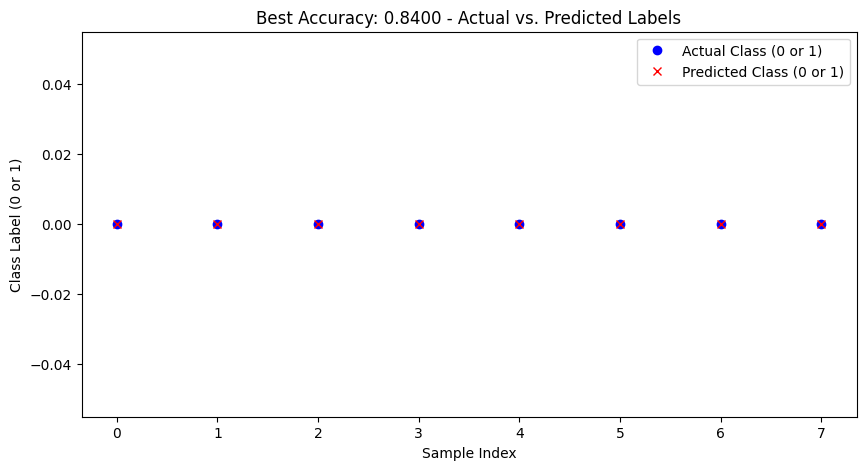

In [ ]:
y_pred241=(best_preds24 > 0.5).astype(int)
# Plot Actual vs. Predicted for Best Accuracy
plt.figure(figsize=(10,5))
plt.plot(best_y_test24, label='Actual Class (0 or 1)', color='blue', marker='o', linestyle='')
plt.plot(y_pred241, label='Predicted Class (0 or 1)', color='red', marker='x', linestyle='')
plt.legend()
plt.title(f'Best Accuracy: {best_acc23:.4f} - Actual vs. Predicted Labels')
plt.xlabel("Sample Index")
plt.ylabel("Class Label (0 or 1)")
plt.show()

In [ ]:
# Predictions and evaluation
y1_pred24 = best_model24.predict(X1_test23).flatten()

accuracy = accuracy_score(y1_test23, (y1_pred24 > 0.5).astype(int))  # Convert probs to binary
f1 = f1_score(y1_test23, (y1_pred24 > 0.5).astype(int))
precision = precision_score(y1_test23, (y1_pred24 > 0.5).astype(int))
recall = recall_score(y1_test23, (y1_pred24 > 0.5).astype(int))
print ("accuracy:",accuracy)
print ("f1:",f1)
print ("precision:",precision)
print ("recall:",recall)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
accuracy: 0.783068783068783
f1: 0.2807017543859649
precision: 0.2857142857142857
recall: 0.27586206896551724


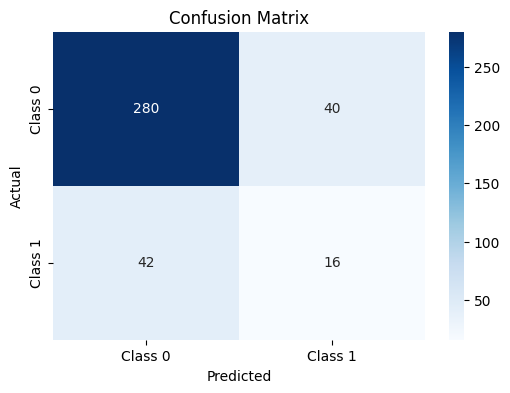

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.88      0.87       320
           1       0.29      0.28      0.28        58

    accuracy                           0.78       378
   macro avg       0.58      0.58      0.58       378
weighted avg       0.78      0.78      0.78       378



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
y_pred = (y1_pred24 > 0.5).astype(int)
# Compute confusion matrix
cm = confusion_matrix(y1_test23, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(y1_test23, y_pred))


In [ ]:
df3 = spy[["Returns"]]*100

n_lags = 24 * 10

for i in range(1, n_lags + 1):
    name = "Ret_" + str(i)
    df3[name] = df3["Returns"].shift(i)

df3["Ret5_i"] = df3["Returns"].rolling(4).apply(lambda x: 100 * (np.prod(1 + x / 100) - 1))
df3["Ret5"] = df3["Ret5_i"].shift(-4)
df3["Output"] = df3["Ret5"] > 0
df3["Output"] = df3["Output"].astype(int)
del df3["Ret5"]
del df3["Ret5_i"]

df3 = df3.dropna()
df3.head(5)


Price,Returns,Ret_1,Ret_2,Ret_3,Ret_4,Ret_5,Ret_6,Ret_7,Ret_8,Ret_9,...,Ret_232,Ret_233,Ret_234,Ret_235,Ret_236,Ret_237,Ret_238,Ret_239,Ret_240,Output
Datetime,,,,,,,,,,,,,,,,,,,,,
2025-01-05 15:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.093055,0.148103,-0.127970,0.026595,0.113176,0.089963,0
2025-01-05 16:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,-0.093055,0.148103,-0.127970,0.026595,0.113176,0
2025-01-05 17:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,-0.093055,0.148103,-0.127970,0.026595,0
2025-01-05 18:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,-0.093055,0.148103,-0.127970,0
2025-01-05 19:30:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,-0.093055,0.148103,0


In [ ]:
train_size = int(0.8 * len(X))
X, y = df3.iloc[:, 1:-1], df3.iloc[:, -1]
X1=X.iloc[:train_size]
X1_test=X.iloc[train_size:]
y1=y.iloc[:train_size]
y1_test=y.iloc[train_size:]
print(X1.shape, y1.shape,X1_test.shape, y1_test.shape)

(1520, 240) (1520,) (381, 240) (381,)


In [ ]:
n_train = 500
n_test = 100

time_backtest = []
time_backtest = np.array(time_backtest)
time_backtest = time_backtest.astype("datetime64", copy=False)

pred_backtest = []
ret_backtest = []

for i in range(0, len(y1) - n_train, n_test):
    X_train, X_test = X1[i : i + (n_train)], X1[i + n_train : i + n_train + n_test]
    y_train, y_test = y1[i : i + (n_train)], y1[i + n_train : i + n_train + n_test]
    test_time = X1.index[i + n_train : i + n_train + n_test].values
    df_selected = X1[i + n_train : i + n_train + n_test]

    # If you need only the first column:
    Ret_vector = df_selected.iloc[:, 0].values  #
    # test_time = X1.index[i + n_train : i + n_train + n_test].values
    # Ret_vector = X1.iloc[i + n_train : i + n_train + n_test, 1].values
    print(
        "ite ",
        i / n_test,
        " -- start test:",
        test_time[0],
        " -- end test",
        test_time[-1],
        " ------- ",
        X_train.shape,
        y_train.shape,
        X_test.shape,
        y_test.shape,
        test_time.shape,
        Ret_vector.shape,
    )
    tf.keras.backend.clear_session()
    tf.random.set_seed(1234)

    model8 = tf.keras.models.Sequential()
    model8.add(tf.keras.layers.Dense(units=hp_units, activation=act_fun))
    model8.add(tf.keras.layers.Dropout(n_dropout))
    model8.add(tf.keras.layers.Dense(units=hp_units_2, activation=act_fun))
    model8.add(tf.keras.layers.Dropout(n_dropout))
    model8.add(tf.keras.layers.Dense(units=hp_units_3, activation=act_fun))
    model8.add(tf.keras.layers.Dropout(n_dropout))
    model8.add(tf.keras.layers.Dense(units=1, activation="sigmoid"))

    hp_lr = 1e-5

    adam = tf.keras.optimizers.Adam(learning_rate=hp_lr)
    model8.compile(optimizer=adam, loss="binary_crossentropy", metrics=["accuracy"])

    es = tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        verbose=0,
        patience=20,
        restore_best_weights=True,
    )
    class_weight = {0: (np.mean(y_train) / 0.5), 1: 1}
    history8 = model8.fit(
        X_train,
        y_train,
        validation_split=0.15,
        epochs=500,
        batch_size=32,
        verbose=0,
        callbacks=[es],
        class_weight=class_weight,
    )

    y_prob = model8.predict(X_test, verbose=0)
    y_pred = np.where(y_prob > 0.50, 1, 0)

    time_backtest = np.append(time_backtest, test_time.flatten())
    pred_backtest = np.append(pred_backtest, y_pred.flatten())
    ret_backtest = np.append(ret_backtest, Ret_vector.flatten())

df_predictions = pd.DataFrame({"Date": time_backtest, "Pred": pred_backtest, "Ret": ret_backtest})

ite  0.0  -- start test: 2025-01-26T11:30:00.000000000  -- end test 2025-01-30T14:30:00.000000000  -------  (500, 240) (500,) (100, 240) (100,) (100,) (100,)
ite  1.0  -- start test: 2025-01-30T15:30:00.000000000  -- end test 2025-02-03T18:30:00.000000000  -------  (500, 240) (500,) (100, 240) (100,) (100,) (100,)
ite  2.0  -- start test: 2025-02-03T19:30:00.000000000  -- end test 2025-02-07T22:30:00.000000000  -------  (500, 240) (500,) (100, 240) (100,) (100,) (100,)
ite  3.0  -- start test: 2025-02-07T23:30:00.000000000  -- end test 2025-02-12T02:30:00.000000000  -------  (500, 240) (500,) (100, 240) (100,) (100,) (100,)
ite  4.0  -- start test: 2025-02-12T03:30:00.000000000  -- end test 2025-02-16T06:30:00.000000000  -------  (500, 240) (500,) (100, 240) (100,) (100,) (100,)
ite  5.0  -- start test: 2025-02-16T07:30:00.000000000  -- end test 2025-02-20T10:30:00.000000000  -------  (500, 240) (500,) (100, 240) (100,) (100,) (100,)
ite  6.0  -- start test: 2025-02-20T11:30:00.0000000

In [ ]:
df_predictions.loc[df_predictions["Pred"] == 0, "Pred"] = -1

df_res = df_predictions
df_res.tail()

,Date,Pred,Ret
1015,2025-03-09 18:30:00,-1.0,0.0
1016,2025-03-09 19:30:00,-1.0,0.0
1017,2025-03-09 20:30:00,-1.0,0.0
1018,2025-03-09 21:30:00,-1.0,0.0
1019,2025-03-09 22:30:00,-1.0,0.0


In [ ]:
df_res["Positions"] = np.where(df_res["Pred"] > 0.5, 1, -1)
df_res["Positions_shift"] = df_res["Positions"].shift(1)
df_res["Strat_ret"] = df_res["Positions"].shift(1) * df_res["Ret"]
df_res["Positions_L"] = df_res["Positions"].shift(1)
df_res["Positions_L"][df_res["Positions_L"] == -1] = 0
df_res["Strat_ret_L"] = df_res["Positions_L"] * df_res["Ret"]
df_res["CumRet"] = df_res["Strat_ret"].expanding().apply(lambda x: np.prod(1 + x) - 1)
df_res["CumRet_L"] = (
    df_res["Strat_ret_L"].expanding().apply(lambda x: np.prod(1 + x) - 1)
)
df_res["bhRet"] = df_res["Ret"].expanding().apply(lambda x: np.prod(1 + x) - 1)

Final_Return_L = np.prod(1 + df_res["Strat_ret_L"]) - 1
Final_Return = np.prod(1 + df_res["Strat_ret"]) - 1
Buy_Return = np.prod(1 + df_res["Ret"]) - 1

print("Strat Return Long Only =", Final_Return_L * 100, "%")
print("Strat Return =", Final_Return * 100, "%")
print("Buy and Hold Return =", Buy_Return * 100, "%")

Strat Return Long Only = -39.93236029565297 %
Strat Return = -99.97455708306067 %
Buy and Hold Return = -99.99999999116172 %


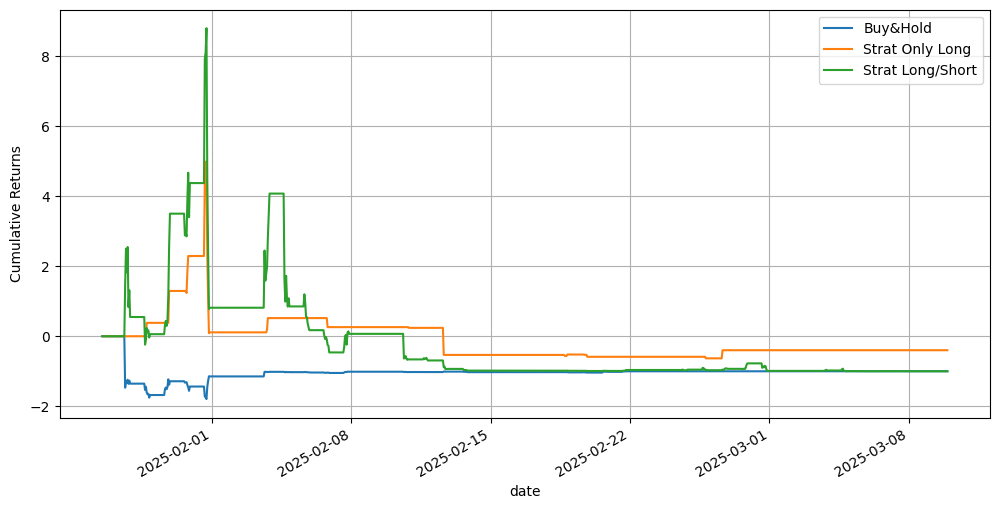

,Date,Pred,Ret,Positions,Positions_shift,Strat_ret,Positions_L,Strat_ret_L,CumRet,CumRet_L,bhRet,trade_bin
count,1020,1020.000000,1020.000000,1020.000000,1019.000000,1019.000000,1019.000000,1019.000000,1019.000000,1019.000000,1020.000000,1019.000000
mean,2025-02-16 17:00:00,-0.809804,-0.005165,-0.809804,-0.809617,0.006890,0.095191,0.000860,-0.230321,-0.110574,-1.036638,0.131501
min,2025-01-26 11:30:00,-1.000000,-1.619940,-1.000000,-1.000000,-0.855191,0.000000,-0.623754,-0.999774,-0.630971,-1.795818,0.000000
25%,2025-02-06 02:15:00,-1.000000,0.000000,-1.000000,-1.000000,-0.000000,0.000000,0.000000,-0.986432,-0.533673,-1.028568,0.000000
50%,2025-02-16 17:00:00,-1.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,-0.954107,-0.399324,-1.013456,0.000000
75%,2025-02-27 07:45:00,-1.000000,0.000000,-1.000000,-1.000000,-0.000000,0.000000,0.000000,0.068410,0.239422,-1.000000,0.000000
max,2025-03-09 22:30:00,1.000000,0.855191,1.000000,1.000000,1.619940,1.000000,0.659525,8.798356,5.000530,0.000000,1.000000
std,NaN,0.586988,0.171690,0.586988,0.587246,0.171714,0.293623,0.050737,1.350314,0.617455,0.223385,0.338114


In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 6))
ax = plt.gca()
df_res.plot(x="Date", y="bhRet", label="Buy&Hold", ax=ax)
df_res.plot(x="Date", y="CumRet_L", label="Strat Only Long", ax=ax)
df_res.plot(x="Date", y="CumRet", label="Strat Long/Short", ax=ax)
plt.xlabel("date")
plt.ylabel("Cumulative Returns")
plt.grid()
plt.show()

df_res["trade_bin"] = df_res["Positions"].diff().abs()
df_res["trade_bin"] = df_res["trade_bin"] / 2
df_res.describe()

## Walk Forward suing CNN-GAF

In [ ]:
# # Standardize features
# scaler = StandardScaler()
# X_scaled23 = scaler.fit_transform(X)

# Convert time series to GAF images
# gaf = GramianAngularField(image_size=15, method='difference')
# X_gaf25 = np.array([gaf.fit_transform(x.reshape(1, -1)) for x in X_lstm])

# # Reshape for CNN input (batch, height, width, channels)
# X_gaf25 = X_gaf25.reshape(-1, 15, 15, 1)

In [ ]:
def build_cnn23():
    model23 = Sequential([
        Conv2D(32, kernel_size=(3,3), activation='tanh', input_shape=X_train_gaf2.shape[1:4]),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.2),

        Conv2D(64, kernel_size=(3,3), activation='tanh'),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.2),

        Flatten(),
        Dense(128, activation='tanh'),
        Dropout(0.2),
        Dense(1)  # Regression output
    ])

    model23.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model23


## Train Test split: 500:500

In [ ]:
# Walk-forward parameters
train_size25 = 500
test_size25 = 500
step_size25 = 200
num_splits25 = (len(X_train_gaf2) - train_size25) // step_size25


# Store results
r2_scores25 = []
mae_scores25 = []
best_r25 = -np.inf
mae25=-np.inf
best_model25 = None
best_preds25 = None
best_y_test25 = None

train_loss = None
val_loss = None

for i in range(num_splits25):
    start_train = i * step_size25
    end_train = start_train + train_size25
    start_test = end_train
    end_test = start_test + test_size25

    X_train25, X_test25 = X_train_gaf2[start_train:end_train], X_train_gaf2[start_test:end_test]
    y_train25, y_test25 = y_train_gaf2[start_train:end_train], y_train_gaf2[start_test:end_test]

    # Train CNN model
    model25 = build_cnn23()
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history23 = model25.fit(X_train25, y_train_gaf2, validation_split=0.2,
                        epochs=50, batch_size=32, verbose=0, callbacks=[early_stopping])

    # Predict and calculate R² score
    y_pred25 = model25.predict(X_test25).flatten()
    r2 = r2_score(y_test25, y_pred25)
    r2_scores25.append(r2)
    mae = mean_absolute_error(y_test25, y_pred25)
    mae_scores25.append(mae)
    print(f"Walk {i+1}/{num_splits25}: R² = {r2:.4f},MAE = {mae:.4f}'")
    if r2 > best_r25:
        best_r25 = r2
        mae25 = mae
        best_model25 = model25
        best_preds25 = y_pred25
        best_y_test25 = y_test25
        train_loss = history23.history['loss']
        val_loss = history23.history['val_loss']



16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Walk 1/11: R² = 0.0975,MAE = 0.5651'
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Walk 2/11: R² = -0.1717,MAE = 0.6225'
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Walk 3/11: R² = -0.1467,MAE = 0.6495'
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Walk 4/11: R² = -0.1547,MAE = 0.7395'
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Walk 5/11: R² = -0.0059,MAE = 0.5942'
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Walk 6/11: R² = -0.2364,MAE = 0.5568'
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Walk 7/11: R² = -0.0579,MAE = 0.5826'
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Walk 8/11: R² = -0.1709,MAE = 0.7307'
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Walk 9/11: R² = -0.0113,MAE = 0.9604'
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Walk 10/11: R² = -0.1024,MAE = 1.1117'
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Walk 11/11: R² = -0.1231,MAE = 1.0089'


In [ ]:
print ("Best R-squared:",best_r25)
print ("Corresponding MAE:",mae25)
print ("Training Loss: ", np.min(train_loss))
print ("Validation Loss: ", np.min(val_loss))

Best R-squared: 0.09750412890963922
Corresponding MAE: 0.5650736510604215
Training Loss:  1.2837811708450317
Validation Loss:  0.5462200045585632


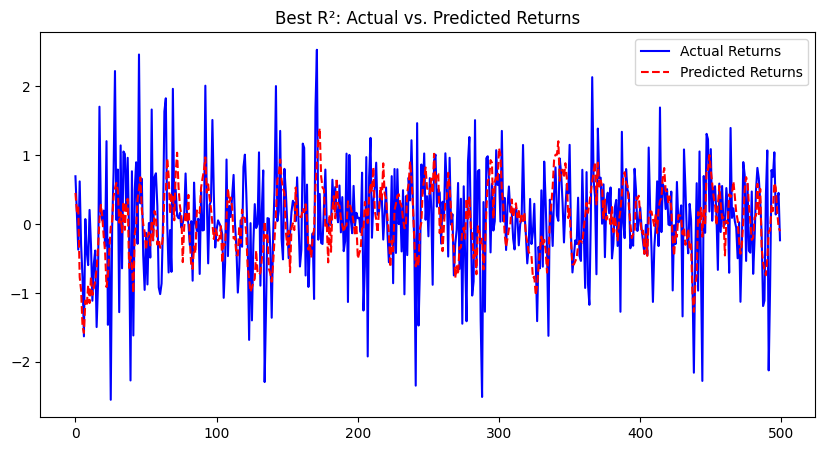

In [ ]:
# Plot Actual vs. Predicted for Best R²
plt.figure(figsize=(10,5))
plt.plot(best_y_test25, label='Actual Returns', color='blue')
plt.plot(best_preds25, label='Predicted Returns', color='red', linestyle='dashed')
plt.legend()
plt.title('Best R²: Actual vs. Predicted Returns')
plt.show()

In [ ]:
# Predictions and evaluation
y_pred25 = best_model25.predict(X_test_gaf2).flatten()

r2 = r2_score(y_test_gaf2, y_pred25)
mae = mean_absolute_error(y_test_gaf2, y_pred25)

print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"R-squared (R²): {r2:.6f}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Mean Absolute Error (MAE): 0.768275
R-squared (R²): 0.149476


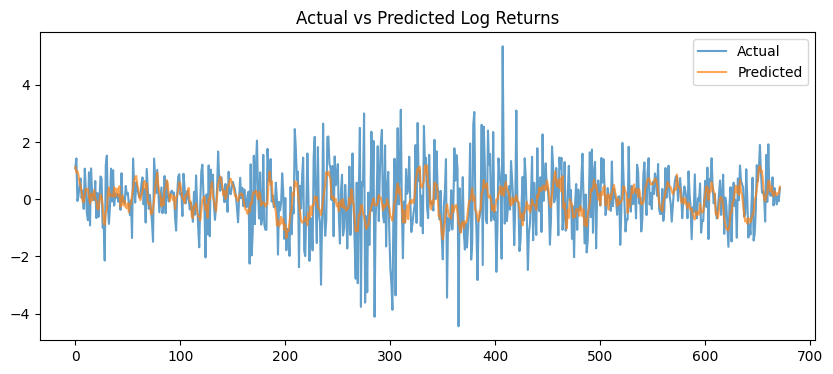

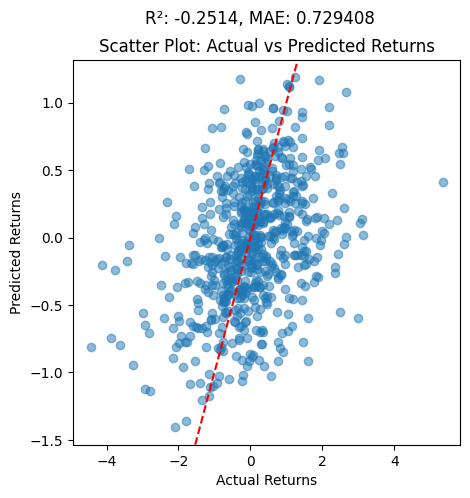

In [ ]:
# Plot actual vs predicted returns
plt.figure(figsize=(10, 4))
plt.plot(y_test_gaf2, label='Actual', alpha=0.7)
plt.plot(y_pred25, label='Predicted', alpha=0.7)
plt.title("Actual vs Predicted Log Returns")
plt.legend()
plt.show()

# Scatter plot of actual vs predicted
plt.figure(figsize=(5, 5))
plt.scatter(y_test_gaf2, y_pred25, alpha=0.5)
plt.xlabel("Actual Returns")
plt.ylabel("Predicted Returns")
plt.title("Scatter Plot: Actual vs Predicted Returns")
plt.axline((0, 0), slope=1, color='red', linestyle='--')  # Reference line
title = f"R²: {r2:.4f}, MAE: {mae:.6f}"
plt.suptitle(title)
plt.show()

## Train Test split: 500:100

In [ ]:
# Walk-forward parameters
train_size26 = 500
test_size26 = 100
step_size26=300
num_splits26 = (len(X_train_gaf2) - train_size26) // step_size26


# Store results
r2_scores26 = []
mae_scores26 = []
best_r26 = -np.inf
mae26=-np.inf
best_model26 = None
best_preds26 = None
best_y_test26 = None

train_loss = None
val_loss = None

for i in range(num_splits26):
    start_train = i * step_size26
    end_train = start_train + train_size26
    start_test = end_train
    end_test = start_test + test_size26

    X_train26, X_test26 = X_train_gaf2[start_train:end_train], X_train_gaf2[start_test:end_test]
    y_train26, y_test26 = y_train_gaf2[start_train:end_train], y_train_gaf2[start_test:end_test]

    # Train CNN model
    model26 = build_cnn23()
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history26 = model26.fit(X_train26, y_train26, validation_split=0.2,
                        epochs=50, batch_size=32, verbose=0, callbacks=[early_stopping])

    # Predict and calculate R² score
    y_pred26 = model25.predict(X_test26).flatten()
    r2 = r2_score(y_test26, y_pred26)
    r2_scores26.append(r2)
    mae = mean_absolute_error(y_test26, y_pred26)
    mae_scores26.append(mae)
    print(f"Walk {i+1}/{num_splits26}: R² = {r2:.4f},MAE = {mae:.4f}'")
    if r2 > best_r26:
        best_r26 = r2
        mae26 = mae
        best_model26 = model26
        best_preds26 = y_pred26
        best_y_test26 = y_test26
        train_loss = history26.history['loss']
        val_loss = history26.history['val_loss']


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Walk 1/7: R² = -0.1717,MAE = 0.7348'
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Walk 2/7: R² = -0.3320,MAE = 0.5718'
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Walk 3/7: R² = -0.0971,MAE = 0.7380'
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Walk 4/7: R² = -0.0865,MAE = 0.9263'
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Walk 5/7: R² = -0.2190,MAE = 0.3703'
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Walk 6/7: R² = -0.3924,MAE = 0.5331'
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Walk 7/7: R² = -0.2514,MAE = 0.7294'


In [ ]:
print ("Best R-squared:",best_r26)
print ("Corresponding MAE:",mae26)
print ("Training Loss: ", np.min(train_loss))
print ("Validation Loss: ", np.min(val_loss))

Best R-squared: -0.0865084914132086
Corresponding MAE: 0.9262913855111619
Training Loss:  0.14157569408416748
Validation Loss:  0.8358808159828186


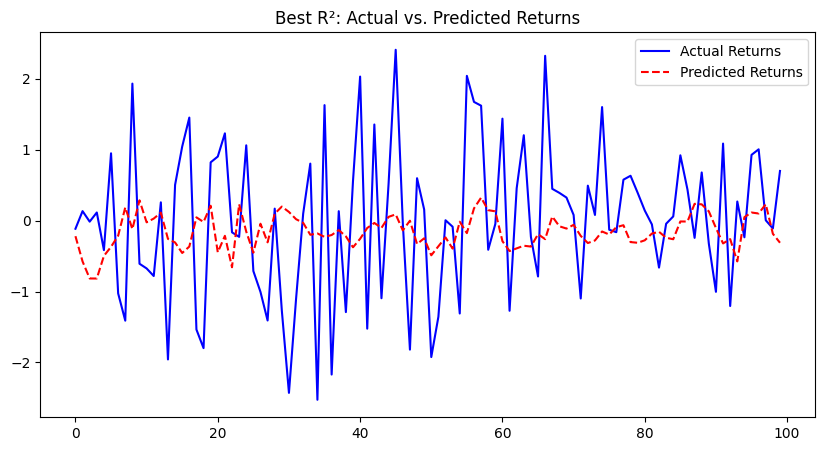

In [ ]:
# Plot Actual vs. Predicted for Best R²
plt.figure(figsize=(10,5))
plt.plot(best_y_test26, label='Actual Returns', color='blue')
plt.plot(best_preds26, label='Predicted Returns', color='red', linestyle='dashed')
plt.legend()
plt.title('Best R²: Actual vs. Predicted Returns')
plt.show()

In [ ]:
# Predictions and evaluation
y_pred26 = best_model26.predict(X_test_gaf2).flatten()

r2 = r2_score(y_test_gaf2, y_pred26)
mae = mean_absolute_error(y_test_gaf2, y_pred26)

print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"R-squared (R²): {r2:.6f}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Mean Absolute Error (MAE): 0.655105
R-squared (R²): 0.355029


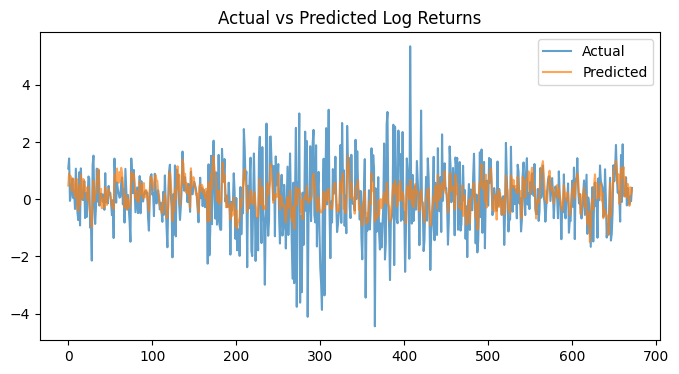

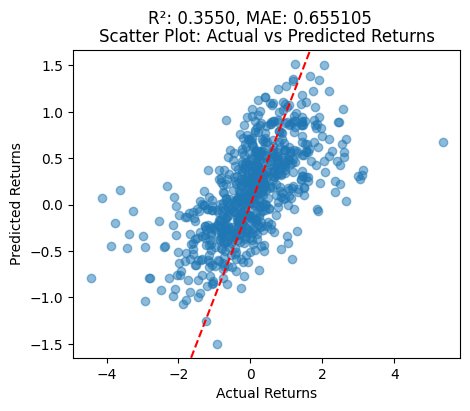

In [ ]:
# Plot actual vs predicted returns
plt.figure(figsize=(8, 4))
plt.plot(y_test_gaf2, label='Actual', alpha=0.7)
plt.plot(y_pred26, label='Predicted', alpha=0.7)
plt.title("Actual vs Predicted Log Returns")
plt.legend()
plt.show()

# Scatter plot of actual vs predicted
plt.figure(figsize=(5, 4))
plt.scatter(y_test_gaf2, y_pred26, alpha=0.5)
plt.xlabel("Actual Returns")
plt.ylabel("Predicted Returns")
plt.title("Scatter Plot: Actual vs Predicted Returns")
plt.axline((0, 0), slope=1, color='red', linestyle='--')  # Reference line
title = f"R²: {r2:.4f}, MAE: {mae:.6f}"
plt.suptitle(title)
plt.show()

## Step 3

b)

In [ ]:
scaler = MinMaxScaler()
X_scaled21 = scaler.fit_transform(X)

window_size21 = 500 # Train size = 500, Test size = 500
step_size21 = 500 # Shift window by 500 observations per iteration
buffer_size21 = 50 # Introduce a 50-observation buffer zone between train and test sets

r2_scores21 = []
mae_scores21 = []
num_splits21 = (len(X_train12) - window_size21 - buffer_size21) // step_size21
y_actual_best21 = None
y_pred_best21 = None
best_r21 = -np.inf
best_model21 = None
mae21 = -np.inf
train_loss = None
val_loss = None

for i in range(num_splits21):
    # Calculate indices with buffer zone
    train_start = i * step_size21
    train_end = train_start + window_size21

    # Add buffer zone
    buffer_start = train_end
    buffer_end = buffer_start + buffer_size21

    # Test set starts after buffer zone
    test_start = buffer_end
    test_end = test_start + window_size21

    # Extract data with buffer zone
    X_train21 = X_train12[train_start:train_end]
    y_train21 = y_train12[train_start:train_end]

    # Test data after buffer
    X_test21 = X_train12[test_start:test_end]
    y_test21 = y_train12[test_start:test_end]

    # Rest of the code remains the same
    model4 = create_model1(X_train21.shape[1], X_train21.shape[2])
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history4 = model4.fit(X_train21, y_train21, validation_split=0.2,
                          epochs=100, batch_size=32, verbose=0, callbacks=[early_stopping])

    y_pred21 = model4.predict(X_test21).flatten()

    r2 = r2_score(y_test21, y_pred21)
    mae = mean_absolute_error(y_test21, y_pred21)

    r2_scores21.append(r2)
    mae_scores21.append(mae)

    if r2 > best_r21:
        best_r21 = r2
        mae21 = mae
        best_model21 = model4
        y_actual_best21 = y_test21
        y_pred_best21 = y_pred21
        train_loss = history4.history['loss']
        val_loss = history4.history['val_loss']

    print(f"Iteration {i+1}/{num_splits21} - R²: {r2:.4f}, MAE: {mae:.6f}")